# Simulación de Decisión Global con N=3 Agentes
## Estimación del Centroide #4 (2.5, 2.5)

Este notebook implementa:
1. Un entorno con 5 centroides predefinidos en ℝ²
2. 3 agentes que intentan estimar el centroide #4
3. Observaciones con ruido Gaussiano (diferente para cada agente)
4. Dinámica de actualización de creencias 
6. Visualización de la evolución de los estados y trayectorias

## 1. Importación de librerías

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
np.random.seed(42)
random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Definición de los Centroides

Definimos 5 puntos en ℝ² como posibles centros de clúster. El objetivo es estimar el centroide #4.

Centroides definidos:
  Centroide 1: [0. 0.]
  Centroide 2: [5. 0.]
  Centroide 3: [0. 5.]
  Centroide 4: [2.5 2.5] <--- OBJETIVO
  Centroide 5: [5. 5.]


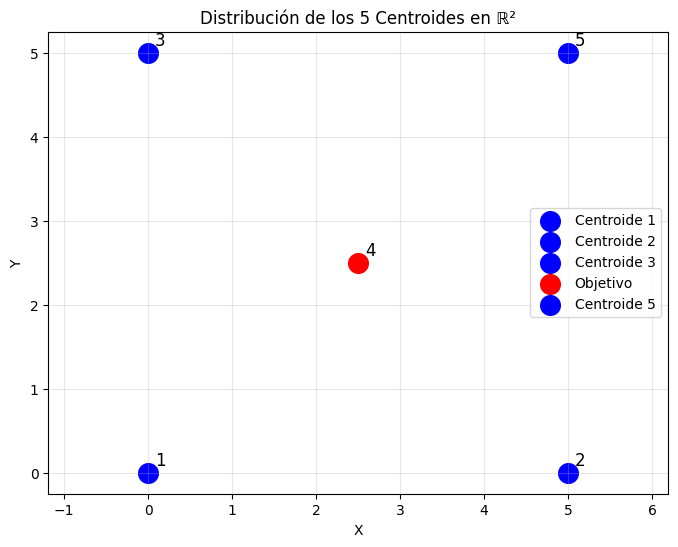

In [16]:
# Definición de los 5 centroides
centroides = {
    0: np.array([0.0, 0.0]),      # Centroide 1
    1: np.array([5.0, 0.0]),      # Centroide 2
    2: np.array([0.0, 5.0]),      # Centroide 3
    3: np.array([2.5, 2.5]),      # Centroide 4 (OBJETIVO)
    4: np.array([5.0, 5.0])       # Centroide 5
}

centroide_objetivo = 3  # Índice del centroide que queremos estimar (2.5, 2.5)
centroide_objetivo_coords = centroides[centroide_objetivo]

print("Centroides definidos:")
for idx, coord in centroides.items():
    marker = " <--- OBJETIVO" if idx == centroide_objetivo else ""
    print(f"  Centroide {idx+1}: {coord}{marker}")

# Visualización
plt.figure(figsize=(8, 6))
for idx, coord in centroides.items():
    color = 'red' if idx == centroide_objetivo else 'blue'
    plt.scatter(coord[0], coord[1], c=color, s=200, marker='o', 
                label=f'Centroide {idx+1}' if idx != centroide_objetivo else 'Objetivo')
    plt.annotate(f'{idx+1}', coord, xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Distribución de los 5 Centroides en ℝ²')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

## 3. Configuración de los Agentes

Cada agente tiene:
- Parámetros de ruido diferentes para sus observaciones
- Una creencia inicial (puede ser aleatoria o centrada)
- Capacidad de actualizar su creencia mediante observaciones y consultas

In [17]:
class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std, creencia_inicial=None):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviación estándar del ruido en observaciones
        
        if creencia_inicial is None:
            # Creencia inicial aleatoria alrededor del centroide objetivo
            self.creencia = centroide_objetivo_coords + np.random.randn(2) * 3.0
        else:
            self.creencia = creencia_inicial.copy()
        
        self.decision = None  # Almacena la decisión final (índice del centroide)
        self.ha_decidido = False
    
    def observar(self):
        """
        Simula una observación del centroide objetivo con ruido.
        Retorna: observación (x, y) con ruido Gaussiano
        """
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        return observacion
    
    def actualizar_por_observacion(self, observacion, beta=2.0, alpha=0.3):
        """
        Actualización aditiva: combinar creencia con observación.
        Es más intuitiva y preserva la escala.
        """
        # Mover hacia la observación con factor alpha
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        return self.creencia
    
    def consultar(self, otras_creencias):
        """
        Actualiza la creencia consultando a otros agentes.
        Combina las creencias usando un promedio ponderado.
        """
        todas_creencias = [self.creencia] + otras_creencias
        self.creencia = np.mean(todas_creencias, axis=0)
        return self.creencia
    
    def decidir(self):
        """
        Decide cuál centroide cree que es el correcto
        basado en la distancia mínima a su creencia actual.
        """
        distancias = {idx: np.linalg.norm(self.creencia - centroide) 
                     for idx, centroide in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.decision = None
        self.ha_decidido = False

## 4. Entorno de Simulación

El entorno gestiona:
- Los 3 agentes
- Las acciones conjuntas
- La función de recompensa
- La evolución del estado

In [71]:
class EntornoDecisionGlobal:
    """Entorno para simulación de decisión global con N agentes"""
    
    def __init__(self, N=3, max_pasos=25):
        self.N = N
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parámetros de ruido para cada agente (diferentes niveles de precisión)
        ruidos = [0.5, 1.0, 1.5]  # Agente 1 más preciso, Agente 3 menos preciso
        
        # Crear agentes
        self.agentes = [Agente(i, ruidos[i]) for i in range(N)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial de estados
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        """
        Retorna el estado actual como un vector de 2N dimensiones.
        Incluye las creencias de todos los agentes y flags de decisión.
        """
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
            estado.append(1.0 if agente.ha_decidido else 0.0)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones, decisiones_anteriores):
        """
        Calcula la recompensa según la función definida.
        """
        # Costo individual de acciones
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) > 1:
            if len(set(decisiones_actuales)) == 1:
                delta_acuerdo = 30  # Todos los que decidieron coinciden
            else:
                delta_acuerdo = -20  # Hay desacuerdo
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1:
                delta_final = 100  # Todos coinciden y es correcto
            else:
                delta_final = -100  # Desacuerdo total
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones_conjuntas):
        """
        Ejecuta un paso en el entorno.
        
        Parámetros:
        - acciones_conjuntas: lista de strings de longitud N
          Cada string puede ser 'esperar', 'observar', 'consultar', 'decidir'
        
        Retorna:
        - nuevo_estado: vector de estado actualizado
        - recompensa: recompensa obtenida
        - done: booleano indicando si el episodio terminó
        - info: información adicional
        """
        self.paso_actual += 1
        
        # Guardar estado antes de la acción
        estado_anterior = self.obtener_estado()
        
        # Ejecutar acciones
        observaciones_realizadas = []
        
        for i, accion in enumerate(acciones_conjuntas):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                observaciones_realizadas.append(obs)
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                # Solo puede decidir si su creencia está cerca de algún centroide
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:  # Umbral de decisión que habrá que ajustar
                    agente.decidir()
            # 'esperar' no hace nada
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones_conjuntas, None)
        
        # Verificar si el episodio terminó
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones_conjuntas)
        
        nuevo_estado = self.obtener_estado()
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return nuevo_estado, recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno para un nuevo episodio"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()
    
    def visualizar_trayectorias(self, titulo="Evolución de las Trayectorias de los Agentes"):
        """
        Visualiza las trayectorias completas de los 3 agentes en un solo gráfico.
        """
        n_pasos = len(self.historial_creencias)
        
        # Crear figura principal para trayectorias
        plt.figure(figsize=(12, 10))
        
        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            plt.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            plt.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points', 
                        fontsize=12, fontweight='bold')
        
        # Colores para cada agente
        colores = ['red', 'green', 'blue']
        estilos_linea = ['-', '--', ':']
        nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']
        
        # Dibujar trayectorias
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            
            # Dibujar línea de trayectoria
            plt.plot(evolucion_x, evolucion_y, color=colores[i], linestyle=estilos_linea[i],
                    linewidth=2.5, alpha=0.7, label=nombres[i])
            
            # Marcar puntos de la trayectoria
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso == 0:
                    plt.scatter(x, y, c=colores[i], s=150, marker='s', 
                              edgecolors='black', linewidth=2, zorder=6)
                elif paso == len(evolucion_x) - 1:
                    plt.scatter(x, y, c=colores[i], s=150, marker='D',
                              edgecolors='black', linewidth=2, zorder=6)
                else:
                    plt.scatter(x, y, c=colores[i], s=50, marker='o', alpha=0.5)
        
        # Añadir flechas para indicar dirección
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            if len(evolucion_x) > 1:
                for j in range(len(evolucion_x)-1):
                    if j % max(1, len(evolucion_x)//5) == 0:  # Solo algunas flechas
                        dx = evolucion_x[j+1] - evolucion_x[j]
                        dy = evolucion_y[j+1] - evolucion_y[j]
                        plt.arrow(evolucion_x[j], evolucion_y[j], dx*0.5, dy*0.5,
                                 head_width=0.1, head_length=0.1, fc=colores[i], ec=colores[i], alpha=0.3)
        
        plt.xlabel('Coordenada X', fontsize=12)
        plt.ylabel('Coordenada Y', fontsize=12)
        plt.title(titulo, fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(loc='best', fontsize=10)
        plt.xlim(-3, 8)
        plt.ylim(-3, 8)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
        plt.gca().set_aspect('equal')
        plt.tight_layout()
        plt.show()
    
    def visualizar_evolucion(self):
        """Visualiza la evolución de las creencias de los agentes en subplots"""
        n_pasos = len(self.historial_creencias)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        colores = ['red', 'green', 'blue']
        nombres = ['Agente 1', 'Agente 2', 'Agente 3']
        
        for i in range(3):
            ax = axes[i]
            
            # Dibujar centroides
            for idx, coord in centroides.items():
                color = 'gold' if idx == centroide_objetivo else 'gray'
                ax.scatter(coord[0], coord[1], c=color, s=100, marker='*', 
                          edgecolors='black', linewidth=1)
                if idx == centroide_objetivo:
                    ax.annotate('Objetivo', coord, xytext=(5, 5), textcoords='offset points')
            
            # Extraer evolución de la creencia del agente i
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            
            # Dibujar trayectoria
            ax.plot(evolucion_x, evolucion_y, 'o-', color=colores[i], 
                   markersize=6, linewidth=2, label=nombres[i])
            
            # Marcar inicio y fin
            ax.scatter(evolucion_x[0], evolucion_y[0], c=colores[i], s=150, 
                      marker='s', edgecolors='black', label='Inicio')
            ax.scatter(evolucion_x[-1], evolucion_y[-1], c=colores[i], s=150, 
                      marker='D', edgecolors='black', label='Final')
            
            # Añadir números de paso
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso % max(1, len(evolucion_x)//5) == 0:
                    ax.annotate(str(paso), (x, y), xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)
            
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_title(f'{nombres[i]} - Ruido STD={self.agentes[i].ruido_std}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_xlim(-3, 8)
            ax.set_ylim(-3, 8)
        
        plt.suptitle(f'Evolución de las Creencias - {n_pasos} pasos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Mostrar recompensas
        print(f"\nRecompensa total del episodio: {sum(self.historial_recompensas):.2f}")
        print(f"Decisiones finales: {[a.decision for a in self.agentes]}")
        print(f"Centroide objetivo: {centroide_objetivo} ({centroide_objetivo_coords})")
        
        # Gráfico de recompensas por paso
        # Gráfico de recompensas por paso y acumulado
        if self.historial_recompensas:
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            # Gráfico 1: Recompensas por paso (original)
            axes[0].plot(range(1, len(self.historial_recompensas)+1), self.historial_recompensas, 
                        'bo-', linewidth=2, markersize=8)
            axes[0].set_xlabel('Paso')
            axes[0].set_ylabel('Recompensa')
            axes[0].set_title('Recompensas por paso')
            axes[0].grid(True, alpha=0.3)
            axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            
            # Gráfico 2: Recompensa acumulada (NUEVO)
            recompensa_acumulada = np.cumsum(self.historial_recompensas)
            axes[1].plot(range(1, len(recompensa_acumulada)+1), recompensa_acumulada, 
                        'go-', linewidth=2, markersize=8, color='green')
            axes[1].set_xlabel('Paso')
            axes[1].set_ylabel('Recompensa Acumulada')
            axes[1].set_title('Recompensa Acumulada por paso')
            axes[1].grid(True, alpha=0.3)
            axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            
            # Añadir valor final como anotación
            valor_final = recompensa_acumulada[-1]
            axes[1].annotate(f'Total: {valor_final:.2f}', 
                            xy=(len(recompensa_acumulada), valor_final),
                            xytext=(-50, 10), textcoords='offset points',
                            fontsize=10, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
            
            plt.tight_layout()
            plt.show()

## 5. Simulación del PDM (sin aprendizaje)

Primero simulamos el entorno con una política fija para ver la evolución de los estados.

=== SIMULACIÓN CON POLÍTICA FIJA ===

Estado inicial (creencias de los 3 agentes):
  Agente 1: (4.49, 0.32)
  Agente 2: (0.06, 3.24)
  Agente 3: (1.40, 1.51)

--- EVOLUCIÓN ---

Paso 1:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (3.85, 0.82)
    Agente 2: (0.71, 3.35)
    Agente 3: (1.86, 2.19)

Paso 2:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (3.50, 1.17)
    Agente 2: (1.17, 2.92)
    Agente 3: (2.20, 2.70)

Paso 3:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (3.08, 1.49)
    Agente 2: (2.24, 2.77)
    Agente 3: (2.69, 3.27)

Paso 4:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (2.96, 1.63)
    Agente 2: (1.87, 2.63)
    Agente 3: (2.76, 2.57)

Paso 5:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:

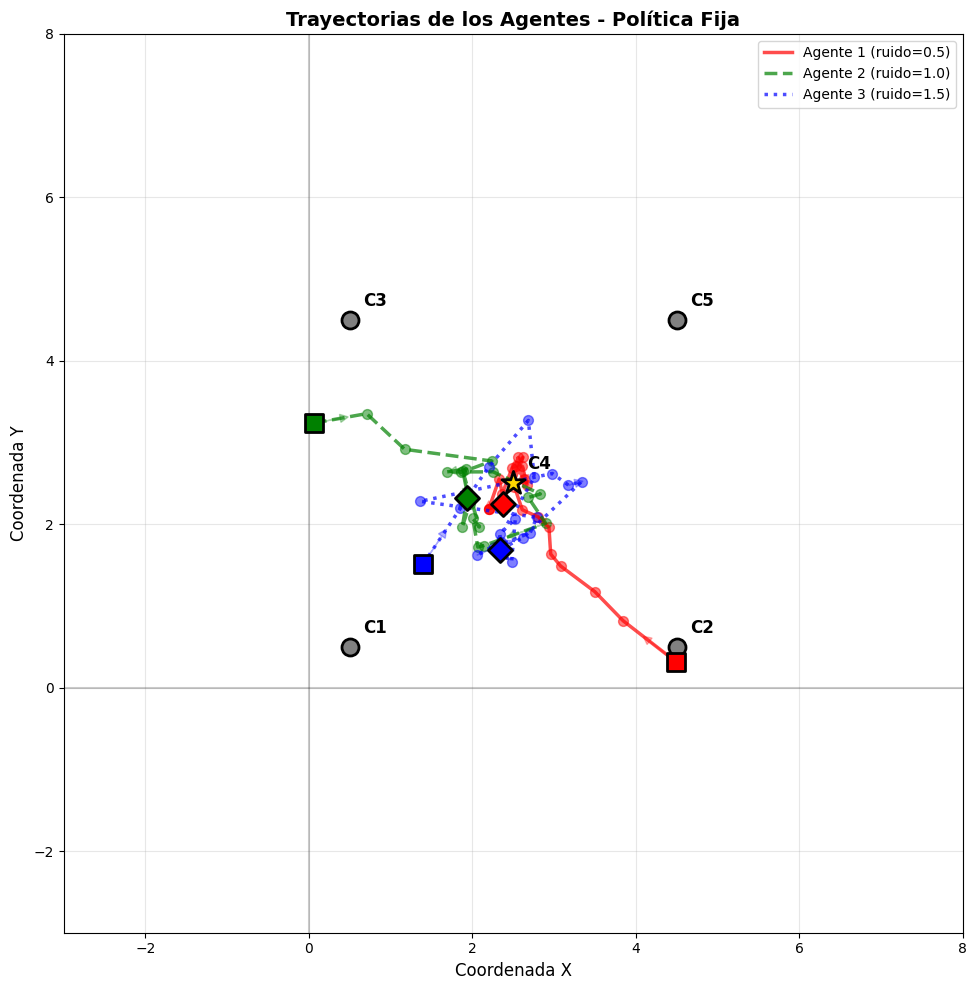

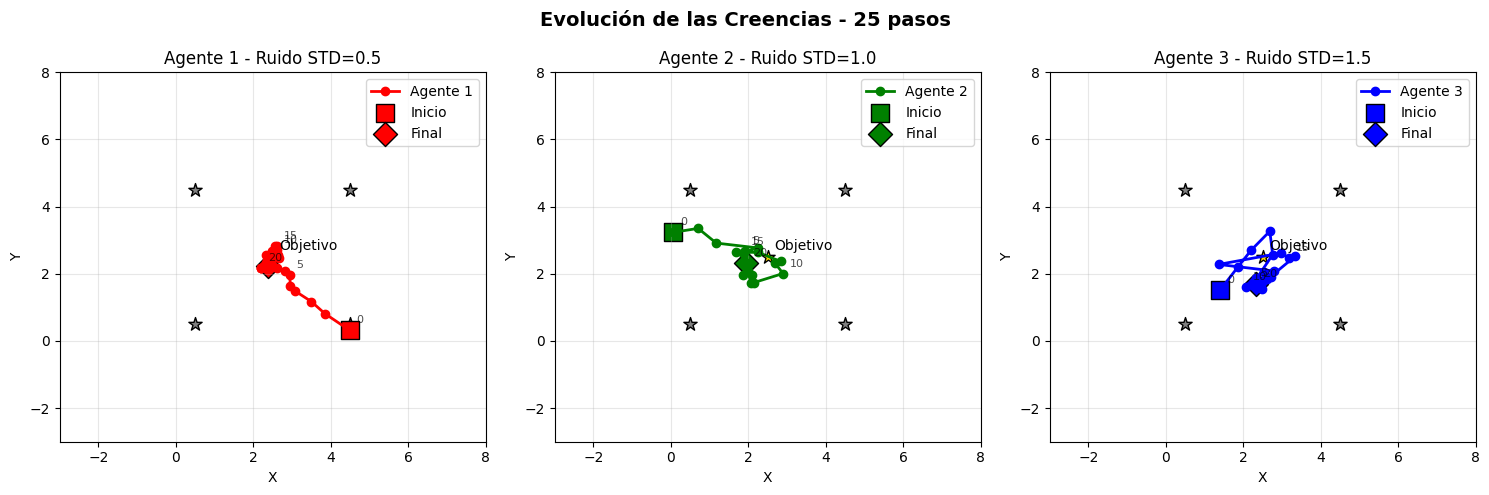


Recompensa total del episodio: 215.00
Decisiones finales: [3, 3, 3]
Centroide objetivo: 3 ([2.5 2.5])


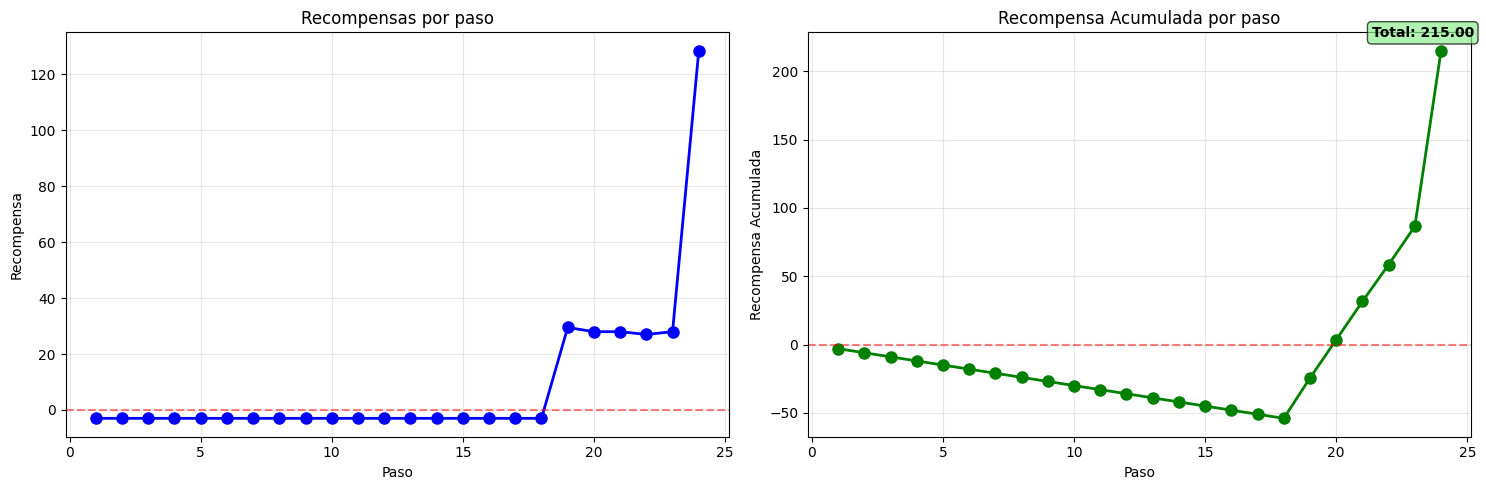

In [72]:
# Crear entorno
env = EntornoDecisionGlobal(N=3, max_pasos=25)

# Política fija para demostración
def politica_fija(paso):
    """
    Política heurística:
    - Pasos 0-3: Todos observan
    - Pasos 4-7: Todos consultan
    - Paso 8+: Todos deciden
    """
    if paso < 18:
        return ['observar', 'observar', 'observar']
    elif paso == 19:
        return ['consultar', 'observar', 'consultar']
    elif paso == 20:
        return ['consultar', 'consultar', 'observar']
    elif paso == 21:
        return ['observar', 'observar', 'observar']
    elif paso == 22:
        return ['consultar', 'observar', 'consultar']
    elif paso == 23:
        return ['decidir', 'consultar', 'observar']
    elif paso == 24:
        return ['consultar', 'consultar', 'consultar']
    elif paso < 26:
        return ['consultar', 'decidir', 'decidir']
    else:
        return ['decidir', 'decidir', 'decidir']

# Ejecutar simulación
estado = env.reset()
print("=== SIMULACIÓN CON POLÍTICA FIJA ===\n")
print(f"Estado inicial (creencias de los 3 agentes):")
for i, agente in enumerate(env.agentes):
    print(f"  Agente {i+1}: ({agente.creencia[0]:.2f}, {agente.creencia[1]:.2f})")

print("\n--- EVOLUCIÓN ---")
done = False
paso = 0

while not done:
    acciones = politica_fija(paso)
    nuevo_estado, recompensa, done, info = env.step(acciones)
    
    print(f"\nPaso {paso + 1}:")
    print(f"  Acciones: {acciones}")
    print(f"  Recompensa: {recompensa:.2f}")
    print(f"  Creencias actuales:")
    for i, creencia in enumerate(info['creencias']):
        print(f"    Agente {i+1}: ({creencia[0]:.2f}, {creencia[1]:.2f})")
    if any(d is not None for d in info['decisiones']):
        print(f"  Decisiones: {info['decisiones']}")
    paso += 1

print(f"\n=== EPISODIO COMPLETADO en {paso} pasos ===")

# Visualizar trayectorias (gráfico único)
env.visualizar_trayectorias("Trayectorias de los Agentes - Política Fija")

# Visualizar evolución detallada (subplots)
env.visualizar_evolucion()

In [73]:
env.historial_creencias

[[array([4.49291779, 0.31587414]),
  array([0.06125534, 3.23625287]),
  array([1.40079741, 1.51425739])],
 [array([3.84802871, 0.81634344]),
  array([0.70739117, 3.35243956]),
  array([1.85564573, 2.19371464])],
 [array([3.50061765, 1.17320329]),
  array([1.17322309, 2.91562269]),
  array([2.20040908, 2.69882559])],
 [array([3.08220006, 1.48667264]),
  array([2.24024962, 2.77201252]),
  array([2.68651622, 3.26908112])],
 [array([2.96020571, 1.63309026]),
  array([1.86570647, 2.63282276]),
  array([2.75945731, 2.57151811])],
 [array([2.93888534, 1.96057699]),
  array([1.92856601, 2.67496922]),
  array([2.26226858, 1.71663931])],
 [array([2.80867824, 2.08706995]),
  array([1.68728638, 2.63901661]),
  array([2.48188581, 1.54035828])],
 [array([2.61241127, 2.17584276]),
  array([2.25684157, 2.63979307]),
  array([2.52684808, 2.06494985])],
 [array([2.51585736, 2.46005206]),
  array([2.83309067, 2.36899772]),
  array([2.33770101, 1.87938989])],
 [array([2.63726405, 2.55141628]),
  array([2.

=== ANIMACIÓN COMPLETADA ===
Recompensa total: 215.00


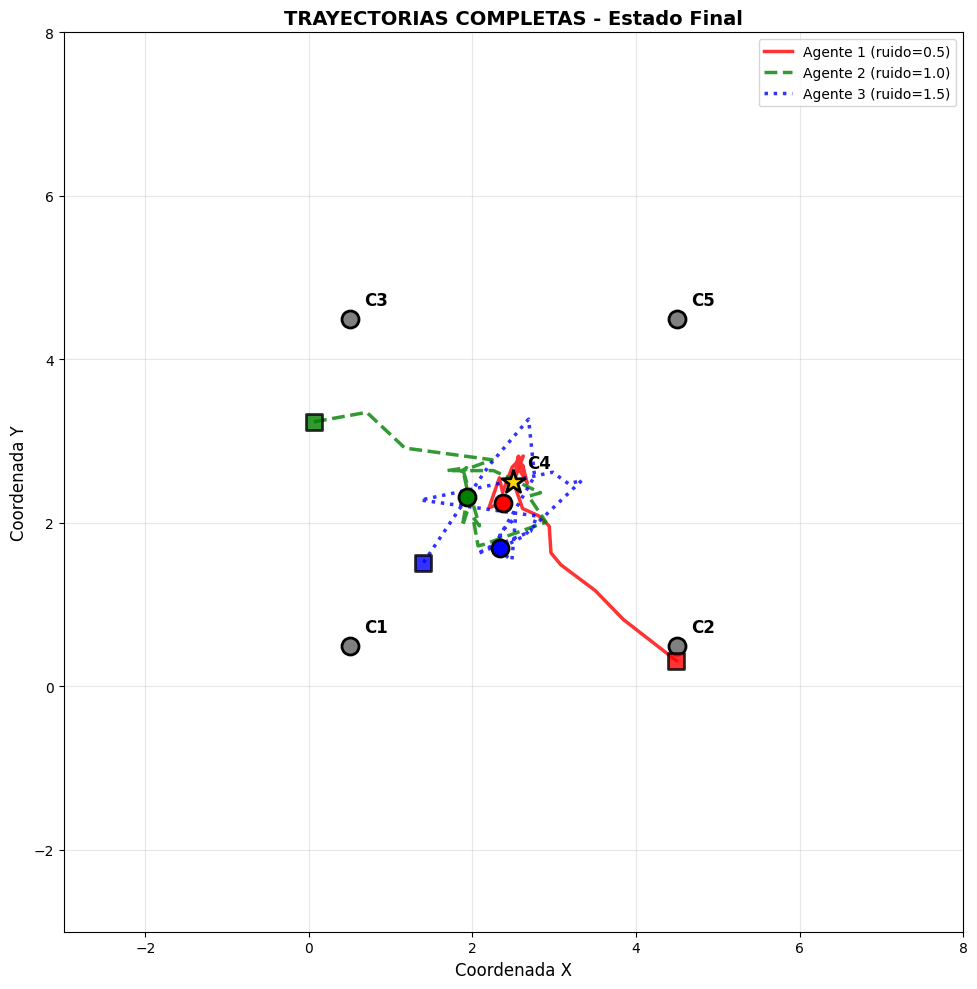

In [74]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

def animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.5):
    """
    Muestra la evolución paso a paso en tiempo real con clear_output.
    
    Parámetros:
    - env: entorno con historial de creencias
    - centroides: diccionario con los centroides
    - centroide_objetivo: índice del centroide objetivo
    - velocidad: tiempo de pausa entre pasos (segundos)
    """
    n_pasos = len(env.historial_creencias)
    
    # Colores y estilos
    colores = ['red', 'green', 'blue']
    estilos = ['-', '--', ':']
    nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']
    
    for paso in range(n_pasos):
        # Limpiar output anterior
        clear_output(wait=True)
        
        # Crear figura
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                        fontsize=12, fontweight='bold')
        
        # Dibujar trayectoria completa hasta el paso actual
        for i in range(3):
            x_data = [env.historial_creencias[t][i][0] for t in range(paso + 1)]
            y_data = [env.historial_creencias[t][i][1] for t in range(paso + 1)]
            
            # Línea de trayectoria
            ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
                   linewidth=2.5, alpha=0.7, label=nombres[i])
            
            # Punto actual
            ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                      edgecolors='black', linewidth=2, zorder=6)
        
        # Marcar inicio
        for i in range(3):
            x_inicio = env.historial_creencias[0][i][0]
            y_inicio = env.historial_creencias[0][i][1]
            ax.scatter(x_inicio, y_inicio, c=colores[i], s=100, marker='s',
                      edgecolors='black', linewidth=1.5, alpha=0.7, zorder=5)
        
        # Configurar gráfico
        ax.set_xlim(-3, 8)
        ax.set_ylim(-3, 8)
        ax.set_xlabel('Coordenada X', fontsize=12)
        ax.set_ylabel('Coordenada Y', fontsize=12)
        ax.set_title(f'Evolución Temporal - Paso {paso}/{n_pasos-1}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend(loc='upper right', fontsize=10)
        
        # Mostrar acciones del paso actual
        if hasattr(env, 'historial_acciones') and paso < len(env.historial_acciones):
            acciones = env.historial_acciones[paso]
            ax.text(0.02, 0.95, f'Acciones: {acciones}', transform=ax.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        # Mostrar información de recompensa
        recompensa_acum = sum(env.historial_recompensas[:paso+1]) if env.historial_recompensas else 0
        info_text = f"Paso: {paso}\nRecompensa acumulada: {recompensa_acum:.2f}"
        ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=10,
               verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.show()
        
        # Pausa para controlar velocidad
        time.sleep(velocidad)
    
    # Mostrar gráfico final estático
    clear_output(wait=True)
    
    print("=== ANIMACIÓN COMPLETADA ===")
    print(f"Recompensa total: {sum(env.historial_recompensas):.2f}")
    
    # Gráfico final estático
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Dibujar centroides
    for idx, coord in centroides.items():
        color = 'gold' if idx == centroide_objetivo else 'gray'
        size = 300 if idx == centroide_objetivo else 150
        marker = '*' if idx == centroide_objetivo else 'o'
        ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                   edgecolors='black', linewidth=2, zorder=5)
        ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold')
    
    # Dibujar trayectorias COMPLETAS
    for i in range(3):
        x_data = [env.historial_creencias[t][i][0] for t in range(n_pasos)]
        y_data = [env.historial_creencias[t][i][1] for t in range(n_pasos)]
        
        ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
               linewidth=2.5, alpha=0.8, label=nombres[i])
        
        # Punto inicial (cuadrado)
        ax.scatter(x_data[0], y_data[0], c=colores[i], s=120, marker='s',
                  edgecolors='black', linewidth=2, zorder=6, alpha=0.8)
        
        # Punto final (círculo)
        ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                  edgecolors='black', linewidth=2, zorder=6)
    
    ax.set_xlim(-3, 8)
    ax.set_ylim(-3, 8)
    ax.set_xlabel('Coordenada X', fontsize=12)
    ax.set_ylabel('Coordenada Y', fontsize=12)
    ax.set_title('TRAYECTORIAS COMPLETAS - Estado Final', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Ejecutar animación en tiempo real
print("=== ANIMACIÓN EN TIEMPO REAL ===\n")
animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.3)

Acciones totales para 2 agentes: 16
ENTRENAMIENTO Q-LEARNING - 2 AGENTES
Estados posibles: 1,296
Acciones posibles: 16
Episodios: 10000
Máximo pasos por episodio: 25
α=0.1, γ=0.95, ε_inicial=0.5
------------------------------------------------------------
Ep  1000: R= -89.4, Éxito=  1.9%, Pasos=13.1, ε=0.500, tiempo=13s
Ep  2000: R= -91.9, Éxito=  0.8%, Pasos=12.5, ε=0.500, tiempo=26s
Ep  3000: R= -73.4, Éxito=  0.4%, Pasos=13.2, ε=0.303, tiempo=42s
Ep  4000: R= -56.3, Éxito=  0.7%, Pasos=14.6, ε=0.184, tiempo=49s
Ep  5000: R= -52.6, Éxito=  0.4%, Pasos=15.7, ε=0.112, tiempo=61s
Ep  6000: R= -39.6, Éxito=  0.3%, Pasos=16.0, ε=0.068, tiempo=69s
Ep  7000: R= -30.9, Éxito=  0.3%, Pasos=16.9, ε=0.050, tiempo=77s
Ep  8000: R= -31.5, Éxito=  0.4%, Pasos=17.3, ε=0.050, tiempo=85s
Ep  9000: R= -21.0, Éxito=  0.5%, Pasos=17.4, ε=0.050, tiempo=94s
Ep 10000: R= -27.2, Éxito=  0.6%, Pasos=17.3, ε=0.050, tiempo=102s
------------------------------------------------------------
ENTRENAMIENTO COMPLETA

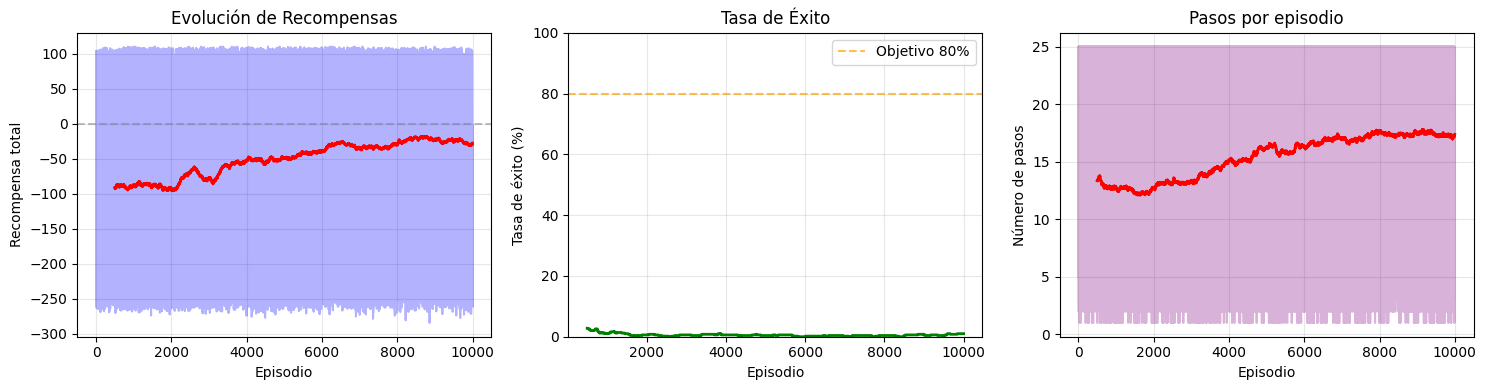


EVALUACIÓN DE LA POLÍTICA APRENDIDA - 2 AGENTES

Resultados sobre 100 pruebas:
  Tasa de éxito: 0.0%
  Recompensa promedio: -13.2
  Recompensa máxima: 108.5
  Recompensa mínima: -253.6
  Pasos promedio: 20.1

Distribución:
  ✓ Éxitos: 0
  ✗ Fallos: 100


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import time

# ============================================================
# 1. CONFIGURACIÓN DEL ESPACIO (2 AGENTES, 6 BINS)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

def discretizar_estado(env):
    """
    Discretiza el estado de 4 dimensiones: (x1, y1, x2, y2)
    """
    estado = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)  # 4 elementos

def ha_decidido(agente):
    """Determina si un agente ha decidido"""
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def obtener_decision(agente):
    """Retorna el índice del centroide elegido o None"""
    for idx, centroide in centroides.items():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return idx
    return None

# ============================================================
# 2. ENTORNO MODIFICADO PARA 2 AGENTES
# ============================================================

class Entorno2Agentes:
    """Entorno simplificado con 2 agentes"""
    
    def __init__(self, max_pasos=25):
        self.N = 2
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parámetros de ruido para cada agente
        ruidos = [0.5, 1.0]  # Agente 1 más preciso, Agente 2 menos preciso
        
        # Crear agentes
        self.agentes = [Agente(i, ruidos[i]) for i in range(2)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones):
        """Función de recompensa original (sin cambios)"""
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) > 1:
            if len(set(decisiones_actuales)) == 1:
                delta_acuerdo = 10
            else:
                delta_acuerdo = -50
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo:
                delta_final = 100
            elif len(set(decisiones)) == 1:
                delta_final = 20
            else:
                delta_final = -200
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso en el entorno"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:
                    agente.decidir()
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones)
        
        # Verificar si terminó
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones)
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return self.obtener_estado(), recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()

# ============================================================
# 3. ACCIONES VÁLIDAS PARA 2 AGENTES
# ============================================================

TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        TODAS_ACCIONES.append((a1, a2))

print(f"Acciones totales para 2 agentes: {len(TODAS_ACCIONES)}")

def acciones_validas(env):
    """Filtra acciones: si ya decidió, solo puede esperar"""
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(2):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================
# 4. AGENTE Q-LEARNING
# ============================================================

class AgenteQLearning:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.5):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(float)
        self.visitas = defaultdict(int)
    
    def seleccionar_accion(self, env):
        estado = discretizar_estado(env)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar')
        
        if random.random() < self.epsilon:
            return random.choice(acciones)
        
        valores = [self.Q[(estado, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, env_siguiente, done):
        estado_siguiente = discretizar_estado(env_siguiente)
        acciones_sig = acciones_validas(env_siguiente)
        
        if done:
            objetivo = recompensa
        else:
            max_futuro = max([self.Q[(estado_siguiente, a)] for a in acciones_sig]) if acciones_sig else 0
            objetivo = recompensa + self.gamma * max_futuro
        
        clave = (estado_anterior, accion)
        self.Q[clave] = self.Q[clave] + self.alpha * (objetivo - self.Q[clave])
        self.visitas[clave] += 1
    
    def reducir_epsilon(self, factor=0.9995, minimo=0.05):
        self.epsilon = max(minimo, self.epsilon * factor)

# ============================================================
# 5. ENTRENAMIENTO (10000 episodios)
# ============================================================

def entrenar(episodios=10000, max_pasos=25, verbose=True):
    agente = AgenteQLearning(alpha=0.1, gamma=0.95, epsilon=0.5)
    
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    print("=" * 60)
    print("ENTRENAMIENTO Q-LEARNING - 2 AGENTES")
    print("=" * 60)
    print(f"Estados posibles: {N_BINS**4:,}")
    print(f"Acciones posibles: {len(TODAS_ACCIONES)}")
    print(f"Episodios: {episodios}")
    print(f"Máximo pasos por episodio: {max_pasos}")
    print(f"α={agente.alpha}, γ={agente.gamma}, ε_inicial={agente.epsilon}")
    print("-" * 60)
    
    start_time = time.time()
    
    for episodio in range(episodios):
        env = Entorno2Agentes(max_pasos=max_pasos)
        estado_actual = discretizar_estado(env)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            
            estado_anterior = estado_actual
            estado_actual = discretizar_estado(env)
            agente.actualizar(estado_anterior, accion, recompensa, env, done)
            pasos += 1
        
        # Verificar éxito
        decisiones = [obtener_decision(a) for a in env.agentes]
        exito = (len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo) if None not in decisiones else False
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Reducir epsilon gradualmente
        if episodio > 2000:
            agente.reducir_epsilon(0.9995)
        
        # Mostrar progreso cada 1000 episodios
        if verbose and (episodio + 1) % 1000 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-1000:])
            avg_success = np.mean(exitos_por_episodio[-1000:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-1000:])
            elapsed = time.time() - start_time
            print(f"Ep {episodio+1:5d}: R={avg_reward:6.1f}, Éxito={avg_success:5.1f}%, "
                  f"Pasos={avg_steps:4.1f}, ε={agente.epsilon:.3f}, tiempo={elapsed:.0f}s")
    
    print("-" * 60)
    print(f"ENTRENAMIENTO COMPLETADO en {time.time() - start_time:.0f} segundos")
    print(f"Tasa de éxito últimos 1000 episodios: {np.mean(exitos_por_episodio[-1000:])*100:.1f}%")
    print(f"Recompensa promedio últimos 1000 episodios: {np.mean(recompensas_por_episodio[-1000:]):.1f}")
    print("=" * 60)
    
    return agente, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio

# ============================================================
# 6. EVALUACIÓN FINAL
# ============================================================

def evaluar(agente, n_pruebas=100):
    """Evalúa la política aprendida (sin exploración)"""
    epsilon_original = agente.epsilon
    agente.epsilon = 0
    
    resultados = []
    
    print("\n" + "=" * 60)
    print("EVALUACIÓN DE LA POLÍTICA APRENDIDA - 2 AGENTES")
    print("=" * 60)
    
    for i in range(n_pruebas):
        env = Entorno2Agentes(max_pasos=25)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [obtener_decision(a) for a in env.agentes]
        exito = (len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo) if None not in decisiones else False
        
        resultados.append((recompensa_total, exito, pasos))
    
    exitos = [r[1] for r in resultados]
    recompensas = [r[0] for r in resultados]
    pasos_list = [r[2] for r in resultados]
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de éxito: {np.mean(exitos)*100:.1f}%")
    print(f"  Recompensa promedio: {np.mean(recompensas):.1f}")
    print(f"  Recompensa máxima: {max(recompensas):.1f}")
    print(f"  Recompensa mínima: {min(recompensas):.1f}")
    print(f"  Pasos promedio: {np.mean(pasos_list):.1f}")
    
    print(f"\nDistribución:")
    print(f"  ✓ Éxitos: {sum(exitos)}")
    print(f"  ✗ Fallos: {n_pruebas - sum(exitos)}")
    
    agente.epsilon = epsilon_original
    return resultados

# ============================================================
# 7. VISUALIZACIÓN
# ============================================================

def graficar_resultados(recompensas, exitos, pasos):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 500
    
    # 1. Recompensas
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolución de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de éxito
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('Tasa de éxito (%)')
    axes[1].set_title('Tasa de Éxito')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('Número de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. EJECUCIÓN PRINCIPAL
# ============================================================

if __name__ == "__main__":
    # Entrenar con 10,000 episodios
    agente, rewards, successes, steps = entrenar(episodios=10000, max_pasos=25)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # Evaluar
    resultados = evaluar(agente, n_pruebas=100)

Inicializando Q con demostraciones...
  Inicializadas 616 entradas en la tabla Q

ENTRENAMIENTO Q-LEARNING CON DEMOSTRACIONES
Estados posibles: 1,296
Episodios de entrenamiento: 5000
ε_inicial=0.3
------------------------------------------------------------
Ep   500: R= -71.1, Éxito=  4.6%, ε=0.300, tiempo=8s
Ep  1000: R= -43.3, Éxito=  4.2%, ε=0.300, tiempo=12s
Ep  1500: R= -46.3, Éxito=  2.2%, ε=0.182, tiempo=15s
Ep  2000: R= -46.0, Éxito=  2.2%, ε=0.110, tiempo=20s
Ep  2500: R= -36.7, Éxito=  3.2%, ε=0.100, tiempo=25s
Ep  3000: R= -24.5, Éxito=  1.8%, ε=0.100, tiempo=29s
Ep  3500: R= -22.2, Éxito=  3.2%, ε=0.100, tiempo=33s
Ep  4000: R= -14.3, Éxito=  4.6%, ε=0.100, tiempo=39s
Ep  4500: R= -21.0, Éxito=  4.4%, ε=0.100, tiempo=45s
Ep  5000: R= -26.5, Éxito=  3.0%, ε=0.100, tiempo=50s
------------------------------------------------------------
Tasa de éxito últimos 500 episodios: 3.0%


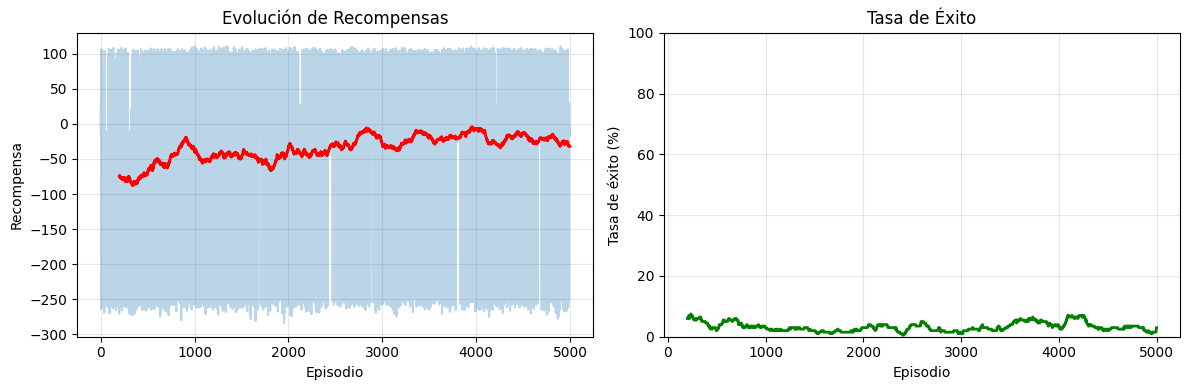


EVALUACIÓN DE LA POLÍTICA APRENDIDA

Resultados sobre 100 pruebas:
  Tasa de éxito: 1.0%
  Recompensa promedio: 5.0
  Recompensa máxima: 109.5
  Recompensa mínima: -252.4


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import time

# ============================================================
# 1. CONFIGURACIÓN (2 AGENTES, 6 BINS)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

def discretizar_estado(env):
    estado = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)

def ha_decidido(agente):
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def obtener_decision(agente):
    for idx, centroide in centroides.items():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return idx
    return None

# ============================================================
# 2. ENTORNO PARA 2 AGENTES
# ============================================================

class Entorno2Agentes:
    def __init__(self, max_pasos=25):
        self.N = 2
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        ruidos = [0.5, 1.0]
        self.agentes = [Agente(i, ruidos[i]) for i in range(2)]
        
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones):
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        delta_acuerdo = 0
        if len(decisiones_actuales) > 1:
            if len(set(decisiones_actuales)) == 1:
                delta_acuerdo = 10
            else:
                delta_acuerdo = -50
        
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo:
                delta_final = 100
            elif len(set(decisiones)) == 1:
                delta_final = 20
            else:
                delta_final = -200
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        self.paso_actual += 1
        
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:
                    agente.decidir()
        
        recompensa = self.calcular_recompensa(acciones)
        
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones)
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return self.obtener_estado(), recompensa, done, info
    
    def reset(self):
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()

# ============================================================
# 3. POLÍTICA EXPERTO (la que ya funciona)
# ============================================================

def politica_experto(paso):
    """
    Política heurística que sabemos que funciona.
    Basada en la política fija que vimos anteriormente.
    """
    if paso < 12:
        return ('observar', 'observar')
    elif paso < 18:
        return ('consultar', 'consultar')
    else:
        return ('decidir', 'decidir')

# ============================================================
# 4. ACCIONES VÁLIDAS
# ============================================================

TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        TODAS_ACCIONES.append((a1, a2))

def acciones_validas(env):
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(2):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================
# 5. AGENTE Q-LEARNING CON INICIALIZACIÓN POR DEMOSTRACIÓN
# ============================================================

class AgenteQLearningConDemostracion:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.3):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(float)
        self.visitas = defaultdict(int)
    
    def inicializar_con_demostraciones(self, n_demostraciones=100, max_pasos=25):
        """
        Inicializa la tabla Q ejecutando la política experta
        y usando los (estado, accion) observados.
        """
        print("Inicializando Q con demostraciones...")
        
        for demo in range(n_demostraciones):
            env = Entorno2Agentes(max_pasos=max_pasos)
            estado_actual = discretizar_estado(env)
            paso = 0
            
            while True:
                accion = politica_experto(paso)
                _, recompensa, done, _ = env.step(accion)
                
                # Dar un valor inicial positivo a este par (estado, accion)
                clave = (estado_actual, accion)
                if self.Q[clave] == 0:
                    self.Q[clave] = 10.0  # Valor inicial optimista
                
                if done:
                    break
                
                estado_actual = discretizar_estado(env)
                paso += 1
        
        print(f"  Inicializadas {len(self.Q)} entradas en la tabla Q")
    
    def seleccionar_accion(self, env):
        estado = discretizar_estado(env)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar')
        
        if random.random() < self.epsilon:
            return random.choice(acciones)
        
        valores = [self.Q[(estado, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, env_siguiente, done):
        estado_siguiente = discretizar_estado(env_siguiente)
        acciones_sig = acciones_validas(env_siguiente)
        
        if done:
            objetivo = recompensa
        else:
            max_futuro = max([self.Q[(estado_siguiente, a)] for a in acciones_sig]) if acciones_sig else 0
            objetivo = recompensa + self.gamma * max_futuro
        
        clave = (estado_anterior, accion)
        self.Q[clave] = self.Q[clave] + self.alpha * (objetivo - self.Q[clave])
        self.visitas[clave] += 1
    
    def reducir_epsilon(self, factor=0.999, minimo=0.1):
        self.epsilon = max(minimo, self.epsilon * factor)

# ============================================================
# 6. ENTRENAMIENTO CON INICIALIZACIÓN
# ============================================================

def entrenar_con_demostracion(episodios=5000, max_pasos=25):
    agente = AgenteQLearningConDemostracion(alpha=0.1, gamma=0.95, epsilon=0.3)
    
    # PASO 1: Inicializar con demostraciones
    agente.inicializar_con_demostraciones(n_demostraciones=200, max_pasos=max_pasos)
    
    recompensas_por_episodio = []
    exitos_por_episodio = []
    
    print("\n" + "=" * 60)
    print("ENTRENAMIENTO Q-LEARNING CON DEMOSTRACIONES")
    print("=" * 60)
    print(f"Estados posibles: {N_BINS**4:,}")
    print(f"Episodios de entrenamiento: {episodios}")
    print(f"ε_inicial={agente.epsilon}")
    print("-" * 60)
    
    start_time = time.time()
    
    for episodio in range(episodios):
        env = Entorno2Agentes(max_pasos=max_pasos)
        estado_actual = discretizar_estado(env)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            
            estado_anterior = estado_actual
            estado_actual = discretizar_estado(env)
            agente.actualizar(estado_anterior, accion, recompensa, env, done)
            pasos += 1
        
        # Verificar éxito
        decisiones = [obtener_decision(a) for a in env.agentes]
        exito = (len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo) if None not in decisiones else False
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        
        # Reducir epsilon
        if episodio > 1000:
            agente.reducir_epsilon(0.999)
        
        # Mostrar progreso cada 500 episodios
        if (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            elapsed = time.time() - start_time
            print(f"Ep {episodio+1:5d}: R={avg_reward:6.1f}, Éxito={avg_success:5.1f}%, "
                  f"ε={agente.epsilon:.3f}, tiempo={elapsed:.0f}s")
    
    print("-" * 60)
    print(f"Tasa de éxito últimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 60)
    
    return agente, recompensas_por_episodio, exitos_por_episodio

# ============================================================
# 7. EVALUACIÓN
# ============================================================

def evaluar(agente, n_pruebas=100):
    epsilon_original = agente.epsilon
    agente.epsilon = 0
    
    exitos = 0
    recompensas = []
    
    print("\n" + "=" * 60)
    print("EVALUACIÓN DE LA POLÍTICA APRENDIDA")
    print("=" * 60)
    
    for i in range(n_pruebas):
        env = Entorno2Agentes(max_pasos=25)
        done = False
        recompensa_total = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
        
        decisiones = [obtener_decision(a) for a in env.agentes]
        exito = (len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo) if None not in decisiones else False
        
        if exito:
            exitos += 1
        recompensas.append(recompensa_total)
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de éxito: {exitos/n_pruebas*100:.1f}%")
    print(f"  Recompensa promedio: {np.mean(recompensas):.1f}")
    print(f"  Recompensa máxima: {max(recompensas):.1f}")
    print(f"  Recompensa mínima: {min(recompensas):.1f}")
    
    agente.epsilon = epsilon_original
    return exitos/n_pruebas

# ============================================================
# 8. EJECUCIÓN
# ============================================================

if __name__ == "__main__":
    # Entrenar
    agente, rewards, successes = entrenar_con_demostracion(episodios=5000, max_pasos=25)
    
    # Graficar
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    ax[0].plot(rewards, alpha=0.3)
    window = 200
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax[0].plot(range(window-1, len(rewards)), ma, 'r-', linewidth=2)
    ax[0].set_xlabel('Episodio')
    ax[0].set_ylabel('Recompensa')
    ax[0].set_title('Evolución de Recompensas')
    ax[0].grid(True, alpha=0.3)
    
    success_rates = []
    for i in range(len(successes) - window + 1):
        success_rates.append(np.mean(successes[i:i+window]) * 100)
    ax[1].plot(range(window-1, len(successes)), success_rates, 'g-', linewidth=2)
    ax[1].set_xlabel('Episodio')
    ax[1].set_ylabel('Tasa de éxito (%)')
    ax[1].set_title('Tasa de Éxito')
    ax[1].grid(True, alpha=0.3)
    ax[1].set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    # Evaluar
    tasa_exito = evaluar(agente, n_pruebas=100)

In [81]:
import numpy as np
from collections import defaultdict
import random
from itertools import product

# ============================================================
# CONFIGURACIÓN DEL ESPACIO (2 AGENTES, 6 BINS)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

# Bins para discretización
bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

# Centroides
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# GENERAR TODOS LOS ESTADOS POSIBLES X
# ============================================================

# Cada estado es (x1, y1, x2, y2) con coordenadas en 0..N_BINS-1
todos_los_estados = list(product(range(N_BINS), repeat=4))
print(f"|X| = {len(todos_los_estados)} estados")

# ============================================================
# GENERAR TODAS LAS ACCIONES POSIBLES
# ============================================================

TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        TODAS_ACCIONES.append((a1, a2))

print(f"|A| = {len(TODAS_ACCIONES)} acciones por agente")

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def discretizar_coordenada(x, y):
    """Convierte coordenadas continuas a bins discretos"""
    bin_x = np.digitize(x, bins_x) - 1
    bin_y = np.digitize(y, bins_y) - 1
    bin_x = max(0, min(N_BINS - 1, bin_x))
    bin_y = max(0, min(N_BINS - 1, bin_y))
    return bin_x, bin_y

def crear_entorno_desde_estado(estado_discreto):
    """
    Crea un entorno con agentes en posiciones específicas.
    estado_discreto: (x1, y1, x2, y2)
    """
    env = Entorno2Agentes(max_pasos=100)  # Horizonte largo para el entrenamiento
    
    for i, agente in enumerate(env.agentes):
        bin_x = estado_discreto[2*i]
        bin_y = estado_discreto[2*i + 1]
        
        # Centro del bin
        x = (bin_x + 0.5) * (X_MAX - X_MIN) / N_BINS + X_MIN
        y = (bin_y + 0.5) * (Y_MAX - Y_MIN) / N_BINS + Y_MIN
        
        agente.creencia = np.array([x, y])
    
    return env

def ha_decidido(agente):
    """Determina si un agente ha decidido (está cerca de un centroide)"""
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def acciones_validas(env):
    """Retorna las acciones válidas en el estado actual del entorno"""
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(2):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

def obtener_estado_discreto(env):
    """Obtiene el estado discreto del entorno actual"""
    estado = []
    for agente in env.agentes:
        x, y = agente.creencia
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)

# ============================================================
# ALGORITMO 3.4.1 (Q-LEARNING)
# ============================================================

def q_learning_algoritmo(N_pasos=10000, gamma=0.95):
    """
    Implementación exacta del Algoritmo 3.4.1
    """
    
    # ============================================================
    # PASO 1: Inicialización
    # ============================================================
    
    # Q0: diccionario que mapea (estado, accion) -> valor
    Q = defaultdict(float)
    
    # Contador de visitas para calcular α_n(x,a)
    visitas = defaultdict(int)
    
    # n = 0
    n = 0
    
    # Seleccionamos un estado inicial X0 arbitrario
    # Tomamos el primer estado de la lista
    Xn = todos_los_estados[0]  # Estado inicial: (0,0,0,0)
    
    print("=" * 60)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 60)
    print(f"N_pasos = {N_pasos}")
    print(f"γ = {gamma}")
    print(f"|X| = {len(todos_los_estados)}")
    print(f"|A| = {len(TODAS_ACCIONES)}")
    print("-" * 60)
    
    # ============================================================
    # BUCLE PRINCIPAL (pasos 2-5)
    # ============================================================
    
    for n in range(N_pasos):
        
        # ========================================================
        # PASO 2: Seleccionar acción Yn = an ∈ A(xn)
        # ========================================================
        
        # Crear entorno a partir del estado Xn
        env = crear_entorno_desde_estado(Xn)
        
        # Obtener acciones válidas en este estado
        acciones_posibles = acciones_validas(env)
        
        if not acciones_posibles:
            # Si no hay acciones válidas, saltamos este paso
            # (esto no debería ocurrir si el estado es válido)
            continue
        
        # Seleccionamos acción siguiendo algún procedimiento
        # Para exploración, usamos ε-greedy con ε decreciente
        epsilon = max(0.1, 1.0 / (n + 1))  # ε decreciente
        if random.random() < epsilon:
            # Exploración: acción aleatoria
            an = random.choice(acciones_posibles)
        else:
            # Explotación: mejor acción según Q actual
            valores = [Q[(Xn, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            an = random.choice(mejores)
        
        # ========================================================
        # PASO 3: Observar resultados
        # ========================================================
        
        # Creamos un nuevo entorno para ejecutar la acción
        env_ejecucion = crear_entorno_desde_estado(Xn)
        
        # Ejecutamos la acción
        _, r, done, _ = env_ejecucion.step(an)
        
        # Obtenemos el nuevo estado Xn+1 = s
        Xn_next = obtener_estado_discreto(env_ejecucion)
        
        # ========================================================
        # PASO 4: Calcular Qn+1(x,a)
        # ========================================================
        
        # Calcular α_n(xn, an) = 1 / (1 + visitas)
        clave_actual = (Xn, an)
        visitas[clave_actual] += 1
        alpha = 1.0 / (1.0 + visitas[clave_actual])
        
        # Calcular Wn(s) = max_{a' ∈ A(s)} Qn(s, a')
        env_siguiente = crear_entorno_desde_estado(Xn_next)
        acciones_siguiente = acciones_validas(env_siguiente)
        
        if done or not acciones_siguiente:
            Wn = 0
        else:
            valores_futuros = [Q[(Xn_next, a)] for a in acciones_siguiente]
            Wn = max(valores_futuros)
        
        # Calcular objetivo de Bellman
        objetivo = r + gamma * Wn
        
        # Actualizar Q solo para (xn, an)
        Q[clave_actual] = (1 - alpha) * Q[clave_actual] + alpha * objetivo
        
        # ========================================================
        # PASO 5: Verificar si n+1 = N
        # ========================================================
        
        # Actualizar Xn para la siguiente iteración
        Xn = Xn_next
        
        # Mostrar progreso cada 1000 pasos
        if (n + 1) % 1000 == 0:
            # Estadísticas
            pares_visitados = len(visitas)
            print(f"n={n+1}: pares visitados={pares_visitados}/{len(todos_los_estados)*len(TODAS_ACCIONES):,}, "
                  f"ε={epsilon:.3f}, α={alpha:.3f}")
    
    # ============================================================
    # PASO 6: Calcular política óptima dN(x)
    # ============================================================
    
    print("\n" + "=" * 60)
    print("PASO 6: Calculando política óptima")
    print("=" * 60)
    
    politica_optima = {}
    
    for estado in todos_los_estados:
        env_estado = crear_entorno_desde_estado(estado)
        acciones_posibles = acciones_validas(env_estado)
        
        if not acciones_posibles:
            politica_optima[estado] = ('esperar', 'esperar')
        else:
            valores = [Q[(estado, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            politica_optima[estado] = random.choice(mejores)
    
    print(f"Política calculada para {len(politica_optima)} estados")
    
    return Q, politica_optima, visitas

# ============================================================
# EJECUTAR ALGORITMO
# ============================================================

print("Iniciando Algoritmo 3.4.1...\n")
Q_final, politica, visitas = q_learning_algoritmo(N_pasos=10000, gamma=0.95)

# ============================================================
# MOSTRAR EJEMPLOS DE LA POLÍTICA APRENDIDA
# ============================================================

print("\n" + "=" * 60)
print("EJEMPLOS DE LA POLÍTICA ÓPTIMA APRENDIDA")
print("=" * 60)

# Mostrar algunos ejemplos de la política
estados_ejemplo = [
    (0, 0, 0, 0),   # Todos en (0,0)
    (5, 5, 5, 5),   # Todos en (5,5)
    (2, 2, 2, 2),   # Todos cerca del objetivo
    (0, 0, 5, 5),   # Agentes en esquinas opuestas
    (3, 3, 4, 4),   # Agentes cerca pero no iguales
]

for estado in estados_ejemplo:
    accion = politica[estado]
    print(f"Estado {estado} → Mejor acción: {accion}")

|X| = 1296 estados
|A| = 16 acciones por agente
Iniciando Algoritmo 3.4.1...

ALGORITMO 3.4.1 - Q-LEARNING
N_pasos = 10000
γ = 0.95
|X| = 1296
|A| = 16
------------------------------------------------------------
n=1000: pares visitados=1/20,736, ε=0.100, α=0.001
n=2000: pares visitados=1/20,736, ε=0.100, α=0.000
n=3000: pares visitados=1/20,736, ε=0.100, α=0.000
n=4000: pares visitados=1/20,736, ε=0.100, α=0.000
n=5000: pares visitados=1/20,736, ε=0.100, α=0.000
n=6000: pares visitados=1/20,736, ε=0.100, α=0.000
n=7000: pares visitados=1/20,736, ε=0.100, α=0.000
n=8000: pares visitados=1/20,736, ε=0.100, α=0.000
n=9000: pares visitados=1/20,736, ε=0.100, α=0.000
n=10000: pares visitados=1/20,736, ε=0.100, α=0.000

PASO 6: Calculando política óptima
Política calculada para 1296 estados

EJEMPLOS DE LA POLÍTICA ÓPTIMA APRENDIDA
Estado (0, 0, 0, 0) → Mejor acción: ('esperar', 'esperar')
Estado (5, 5, 5, 5) → Mejor acción: ('esperar', 'esperar')
Estado (2, 2, 2, 2) → Mejor acción: ('obser

In [83]:
Q_final

defaultdict(float,
            {((0, 0, 0, 0), ('esperar', 'esperar')): -2.848738440155535,
             ((0, 0, 0, 1), ('esperar', 'esperar')): 0.0,
             ((0, 0, 0, 1), ('esperar', 'observar')): 0.0,
             ((0, 0, 0, 1), ('esperar', 'consultar')): 0.0,
             ((0, 0, 0, 1), ('esperar', 'decidir')): 0.0,
             ((0, 0, 0, 2), ('esperar', 'esperar')): 0.0,
             ((0, 0, 0, 2), ('esperar', 'observar')): 0.0,
             ((0, 0, 0, 2), ('esperar', 'consultar')): 0.0,
             ((0, 0, 0, 2), ('esperar', 'decidir')): 0.0,
             ((0, 0, 0, 3), ('esperar', 'esperar')): 0.0,
             ((0, 0, 0, 3), ('esperar', 'observar')): 0.0,
             ((0, 0, 0, 3), ('esperar', 'consultar')): 0.0,
             ((0, 0, 0, 3), ('esperar', 'decidir')): 0.0,
             ((0, 0, 0, 4), ('esperar', 'esperar')): 0.0,
             ((0, 0, 0, 4), ('esperar', 'observar')): 0.0,
             ((0, 0, 0, 4), ('esperar', 'consultar')): 0.0,
             ((0, 0, 0, 4)

In [89]:
import numpy as np
from collections import defaultdict
import random
from itertools import product

# ============================================================
# CONFIGURACIÓN DEL ESPACIO (3 AGENTES, 6 BINS)
# ============================================================

N_BINS = 12
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

# Bins para discretización
bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

# Centroides (los mismos)
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# GENERAR TODOS LOS ESTADOS POSIBLES X (3 agentes)
# ============================================================

# Cada estado es (x1, y1, x2, y2, x3, y3) con coordenadas en 0..N_BINS-1
todos_los_estados = list(product(range(N_BINS), repeat=6))
print(f"|X| = {len(todos_los_estados)} estados")  # 6^6 = 46,656

# ============================================================
# GENERAR TODAS LAS ACCIONES POSIBLES (3 agentes)
# ============================================================

TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        for a3 in ['esperar', 'observar', 'consultar', 'decidir']:
            TODAS_ACCIONES.append((a1, a2, a3))

print(f"|A| = {len(TODAS_ACCIONES)} acciones")  # 4^3 = 64

# ============================================================
# FUNCIONES AUXILIARES (modificadas para 3 agentes)
# ============================================================

def discretizar_coordenada(x, y):
    """Convierte coordenadas continuas a bins discretos"""
    bin_x = np.digitize(x, bins_x) - 1
    bin_y = np.digitize(y, bins_y) - 1
    bin_x = max(0, min(N_BINS - 1, bin_x))
    bin_y = max(0, min(N_BINS - 1, bin_y))
    return bin_x, bin_y

def crear_entorno_desde_estado(estado_discreto):
    """
    Crea un entorno con 3 agentes en posiciones específicas.
    estado_discreto: (x1, y1, x2, y2, x3, y3)
    """
    env = EntornoDecisionGlobal(N=3, max_pasos=100)  # Usamos tu entorno original con 3 agentes
    
    for i, agente in enumerate(env.agentes):
        bin_x = estado_discreto[2*i]
        bin_y = estado_discreto[2*i + 1]
        
        # Centro del bin
        x = (bin_x + 0.5) * (X_MAX - X_MIN) / N_BINS + X_MIN
        y = (bin_y + 0.5) * (Y_MAX - Y_MIN) / N_BINS + Y_MIN
        
        agente.creencia = np.array([x, y])
    
    return env

def ha_decidido(agente):
    """Determina si un agente ha decidido (está cerca de un centroide)"""
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def acciones_validas(env):
    """
    Retorna las acciones válidas en el estado actual del entorno.
    Para 3 agentes: si un agente ya decidió, solo puede 'esperar'.
    """
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):  # 3 agentes
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    
    return validas

def obtener_estado_discreto(env):
    """
    Obtiene el estado discreto del entorno actual para 3 agentes.
    """
    estado = []
    for agente in env.agentes:
        x, y = agente.creencia
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)  # 6 elementos

# ============================================================
# ALGORITMO 3.4.1 (Q-LEARNING) PARA 3 AGENTES
# ============================================================

def q_learning_3agentes(N_pasos=20000, gamma=0.95):
    """
    Implementación exacta del Algoritmo 3.4.1 para 3 agentes.
    """
    
    # ============================================================
    # PASO 1: Inicialización
    # ============================================================
    
    Q = defaultdict(float)
    visitas = defaultdict(int)
    
    # Estado inicial arbitrario (todos en el origen)
    Xn = (0, 0, 0, 0, 0, 0)
    
    print("=" * 60)
    print("ALGORITMO 3.4.1 - Q-LEARNING PARA 3 AGENTES")
    print("=" * 60)
    print(f"N_pasos = {N_pasos}")
    print(f"γ = {gamma}")
    print(f"|X| = {len(todos_los_estados):,} estados")
    print(f"|A| = {len(TODAS_ACCIONES)} acciones")
    print("-" * 60)
    
    # ============================================================
    # BUCLE PRINCIPAL (pasos 2-5)
    # ============================================================
    
    for n in range(N_pasos):
        
        # ========================================================
        # PASO 2: Seleccionar acción Yn = an ∈ A(xn)
        # ========================================================
        
        env = crear_entorno_desde_estado(Xn)
        acciones_posibles = acciones_validas(env)
        
        if not acciones_posibles:
            continue
        
        # ε decreciente
        epsilon = max(0.1, 1.0 / (n + 1))
        
        if random.random() < epsilon:
            # Exploración: acción aleatoria
            an = random.choice(acciones_posibles)
        else:
            # Explotación: mejor acción según Q
            valores = [Q[(Xn, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            an = random.choice(mejores)
        
        # ========================================================
        # PASO 3: Observar resultados
        # ========================================================
        
        env_ejecucion = crear_entorno_desde_estado(Xn)
        _, r, done, _ = env_ejecucion.step(an)
        Xn_next = obtener_estado_discreto(env_ejecucion)
        
        # ========================================================
        # PASO 4: Actualizar Q solo para (xn, an)
        # ========================================================
        
        clave_actual = (Xn, an)
        visitas[clave_actual] += 1
        alpha = 1.0 / (1.0 + visitas[clave_actual])
        
        # Calcular Wn(s) = max_{a'} Q(s, a')
        env_siguiente = crear_entorno_desde_estado(Xn_next)
        acciones_siguiente = acciones_validas(env_siguiente)
        
        if done or not acciones_siguiente:
            Wn = 0
        else:
            valores_futuros = [Q[(Xn_next, a)] for a in acciones_siguiente]
            Wn = max(valores_futuros)
        
        objetivo = r + gamma * Wn
        Q[clave_actual] = (1 - alpha) * Q[clave_actual] + alpha * objetivo
        
        # ========================================================
        # PASO 5: Actualizar Xn para la siguiente iteración
        # ========================================================
        
        Xn = Xn_next
        
        # Mostrar progreso cada 2000 pasos
        if (n + 1) % 2000 == 0:
            pares_visitados = len(visitas)
            pares_totales = len(todos_los_estados) * len(TODAS_ACCIONES)
            print(f"n={n+1}: pares visitados={pares_visitados:,}/{pares_totales:,} "
                  f"({pares_visitados/pares_totales*100:.1f}%), "
                  f"ε={epsilon:.3f}, α={alpha:.3f}")
    
    # ============================================================
    # PASO 6: Calcular política óptima dN(x)
    # ============================================================
    
    print("\n" + "=" * 60)
    print("PASO 6: Calculando política óptima para 3 agentes")
    print("=" * 60)
    
    politica_optima = {}
    
    # Solo calculamos para algunos estados (por simplicidad)
    # En la práctica, podríamos calcular para todos
    estados_muestra = [
        (0, 0, 0, 0, 0, 0),  # Todos en origen
        (5, 5, 5, 5, 5, 5),  # Todos en esquina superior derecha
        (3, 3, 3, 3, 3, 3),  # Todos cerca del objetivo
        (0, 0, 5, 5, 2, 2),  # Agentes dispersos
    ]
    
    for estado in estados_muestra:
        env_estado = crear_entorno_desde_estado(estado)
        acciones_posibles = acciones_validas(env_estado)
        
        if not acciones_posibles:
            politica_optima[estado] = ('esperar', 'esperar', 'esperar')
        else:
            valores = [Q[(estado, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            politica_optima[estado] = random.choice(mejores)
    
    return Q, politica_optima, visitas

# ============================================================
# EJECUTAR ALGORITMO PARA 3 AGENTES
# ============================================================

print("Iniciando Algoritmo 3.4.1 para 3 agentes...\n")
Q_final, politica, visitas = q_learning_3agentes(N_pasos=20000, gamma=0.95)

# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("POLÍTICA ÓPTIMA APRENDIDA PARA 3 AGENTES")
print("=" * 60)

for estado, accion in politica.items():
    print(f"Estado {estado} → Mejor acción: {accion}")

# Estadísticas finales
print("\n" + "=" * 60)
print("ESTADÍSTICAS FINALES")
print("=" * 60)
print(f"Pares (estado, acción) visitados: {len(visitas):,}")
print(f"Total de pares posibles: {len(todos_los_estados) * len(TODAS_ACCIONES):,}")
print(f"Cobertura: {len(visitas)/(len(todos_los_estados)*len(TODAS_ACCIONES))*100:.2f}%")

|X| = 2985984 estados
|A| = 64 acciones
Iniciando Algoritmo 3.4.1 para 3 agentes...

ALGORITMO 3.4.1 - Q-LEARNING PARA 3 AGENTES
N_pasos = 20000
γ = 0.95
|X| = 2,985,984 estados
|A| = 64 acciones
------------------------------------------------------------
n=2000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=4000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=6000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=8000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=10000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=12000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=14000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=16000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=18000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000
n=20000: pares visitados=1/191,102,976 (0.0%), ε=0.100, α=0.000

PASO 6: Calculando política óptima para 3 agentes

POLÍTICA ÓPTIMA APRENDIDA PARA 3 AGENTES
Estado (0, 0, 

In [90]:
Q_final

defaultdict(float,
            {((0, 0, 0, 0, 0, 0),
              ('esperar', 'esperar', 'esperar')): -4.536286459863352,
             ((5, 5, 5, 5, 5, 5), ('esperar', 'esperar', 'esperar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'esperar', 'esperar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'esperar', 'observar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'esperar', 'consultar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'esperar', 'decidir')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'observar', 'esperar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'observar', 'observar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'observar', 'consultar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'observar', 'decidir')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'consultar', 'esperar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('esperar', 'consultar', 'observar')): 0.0,
             ((3, 3, 3, 3, 3, 3), ('e

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# ============================================================
# SIMULACIÓN SIGUIENDO LA POLÍTICA ÓPTIMA
# ============================================================

def simular_politica_optima(politica_optima, max_pasos=50, verbose=True, animar=False, velocidad=0.5):
    """
    Simula un episodio completo siguiendo la política óptima aprendida.
    
    Parámetros:
    - politica_optima: diccionario {estado_discreto: accion}
    - max_pasos: máximo de pasos por episodio
    - verbose: si es True, imprime información paso a paso
    - animar: si es True, muestra animación gráfica
    - velocidad: velocidad de la animación (segundos por paso)
    
    Retorna:
    - env: entorno con el historial completo
    - recompensa_total: suma de recompensas del episodio
    - decisiones_finales: decisiones de cada agente
    - exito: True si todos acertaron al centroide objetivo
    """
    
    # Crear entorno nuevo
    env = EntornoDecisionGlobal(N=3, max_pasos=max_pasos)
    
    # Obtener estado inicial
    estado_actual = obtener_estado_discreto(env)
    done = False
    recompensa_total = 0
    paso = 0
    
    if verbose:
        print("=" * 60)
        print("SIMULACIÓN CON POLÍTICA ÓPTIMA")
        print("=" * 60)
        print(f"\nEstado inicial:")
        for i, agente in enumerate(env.agentes):
            print(f"  Agente {i+1}: ({agente.creencia[0]:.2f}, {agente.creencia[1]:.2f})")
        print()
    
    # Si hay animación, preparamos la figura
    if animar:
        plt.figure(figsize=(12, 10))
    
    while not done and paso < max_pasos:
        
        # ====================================================
        # 1. Obtener acción óptima para el estado actual
        # ====================================================
        
        # Buscar la acción en la política aprendida
        if estado_actual in politica_optima:
            accion = politica_optima[estado_actual]
        else:
            # Si el estado no fue visitado, usar acción por defecto
            # Política conservadora: todos observan
            accion = ('observar', 'observar', 'observar')
            if verbose:
                print(f"  [!] Estado {estado_actual} no visitado, usando acción por defecto")
        
        # ====================================================
        # 2. Ejecutar acción
        # ====================================================
        
        _, recompensa, done, info = env.step(accion)
        recompensa_total += recompensa
        
        # ====================================================
        # 3. Mostrar información (si verbose)
        # ====================================================
        
        if verbose:
            print(f"Paso {paso + 1}:")
            print(f"  Acción: {accion}")
            print(f"  Recompensa: {recompensa:.2f} (acum: {recompensa_total:.2f})")
            print(f"  Creencias actuales:")
            for i, creencia in enumerate(info['creencias']):
                print(f"    Agente {i+1}: ({creencia[0]:.2f}, {creencia[1]:.2f})")
            
            # Mostrar decisiones si las hay
            decisiones_actuales = []
            for i, agente in enumerate(env.agentes):
                if agente.ha_decidido:
                    decisiones_actuales.append(f"A{i+1}→C{agente.decision+1}")
            if decisiones_actuales:
                print(f"  Decisiones: {', '.join(decisiones_actuales)}")
            print()
        
        # ====================================================
        # 4. Animación (si está activada)
        # ====================================================
        
        if animar:
            clear_output(wait=True)
            
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # Dibujar centroides
            for idx, coord in centroides.items():
                color = 'gold' if idx == centroide_objetivo else 'gray'
                size = 300 if idx == centroide_objetivo else 150
                marker = '*' if idx == centroide_objetivo else 'o'
                ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                          edgecolors='black', linewidth=2, zorder=5)
                ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                           fontsize=12, fontweight='bold')
            
            # Dibujar trayectorias
            colores = ['red', 'green', 'blue']
            estilos = ['-', '--', ':']
            nombres = ['Agente 1', 'Agente 2', 'Agente 3']
            
            n_pasos_hist = len(env.historial_creencias)
            
            for i in range(3):
                x_data = [env.historial_creencias[t][i][0] for t in range(n_pasos_hist)]
                y_data = [env.historial_creencias[t][i][1] for t in range(n_pasos_hist)]
                
                ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
                       linewidth=2.5, alpha=0.7, label=nombres[i])
                
                # Punto actual
                ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                          edgecolors='black', linewidth=2, zorder=6)
            
            # Marcar inicio
            for i in range(3):
                x_inicio = env.historial_creencias[0][i][0]
                y_inicio = env.historial_creencias[0][i][1]
                ax.scatter(x_inicio, y_inicio, c=colores[i], s=100, marker='s',
                          edgecolors='black', linewidth=1.5, alpha=0.7)
            
            ax.set_xlim(-2, 7)
            ax.set_ylim(-2, 7)
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_title(f'Paso {paso+1} - Recompensa acum: {recompensa_total:.1f}')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')
            ax.legend(loc='upper right')
            
            # Mostrar acción
            ax.text(0.02, 0.95, f'Acción: {accion}', transform=ax.transAxes,
                   fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
            
            plt.show()
            time.sleep(velocidad)
        
        # Actualizar para siguiente paso
        estado_actual = obtener_estado_discreto(env)
        paso += 1
    
    # ====================================================
    # 5. Resultados finales
    # ====================================================
    
    # Obtener decisiones finales
    decisiones_finales = []
    for i, agente in enumerate(env.agentes):
        if agente.ha_decidido:
            decisiones_finales.append(agente.decision)
        else:
            decisiones_finales.append(None)
    
    # Verificar éxito (todos decidieron y acertaron)
    exito = False
    if None not in decisiones_finales:
        if len(set(decisiones_finales)) == 1 and decisiones_finales[0] == centroide_objetivo:
            exito = True
    
    if verbose:
        print("=" * 60)
        print("RESULTADOS DE LA SIMULACIÓN")
        print("=" * 60)
        print(f"Pasos totales: {paso}")
        print(f"Recompensa total: {recompensa_total:.2f}")
        print(f"Decisiones finales: {[d+1 if d is not None else '?' for d in decisiones_finales]}")
        print(f"Centroide objetivo: {centroide_objetivo+1} ({centroides[centroide_objetivo]})")
        print(f"Éxito: {'✓' if exito else '✗'}")
    
    # Si hay animación, mostrar gráfico final estático
    if animar:
        print("\nMostrando gráfico final estático...")
        env.visualizar_trayectorias("Trayectorias - Política Óptima")
    
    return env, recompensa_total, decisiones_finales, exito

# ============================================================
# EJECUTAR SIMULACIÓN CON LA POLÍTICA APRENDIDA
# ============================================================

# Primero, necesitamos tener la política óptima del entrenamiento
# Suponemos que 'politica' es el diccionario que obtuvimos del algoritmo Q-learning

print("Iniciando simulación con política óptima...\n")

# Ejecutar simulación (sin animación, solo verbose)
env_final, recompensa, decisiones, exito = simular_politica_optima(
    politica_optima=politica,  # La política que aprendiste
    max_pasos=25,
    verbose=True,
    animar=False
)

# ============================================================
# SIMULAR MÚLTIPLES EPISODIOS PARA EVALUAR LA POLÍTICA
# ============================================================

def evaluar_politica_optima(politica_optima, n_episodios=100, max_pasos=25):
    """
    Evalúa la política óptima en múltiples episodios.
    """
    
    exitos = 0
    recompensas = []
    pasos_totales = []
    
    print("\n" + "=" * 60)
    print(f"EVALUANDO POLÍTICA ÓPTIMA EN {n_episodios} EPISODIOS")
    print("=" * 60)
    
    for i in range(n_episodios):
        _, recompensa, decisiones, exito_ep = simular_politica_optima(
            politica_optima=politica_optima,
            max_pasos=max_pasos,
            verbose=False
        )
        
        if exito_ep:
            exitos += 1
        recompensas.append(recompensa)
        pasos_totales.append(len(env_final.historial_creencias) - 1)
        
        if (i + 1) % 20 == 0:
            print(f"  Episodios {i+1}/{n_episodios}: éxito={exitos}/{i+1} ({exitos/(i+1)*100:.1f}%)")
    
    print("\n" + "=" * 60)
    print("RESULTADOS DE LA EVALUACIÓN")
    print("=" * 60)
    print(f"Tasa de éxito: {exitos/n_episodios*100:.1f}%")
    print(f"Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"Recompensa máxima: {max(recompensas):.2f}")
    print(f"Recompensa mínima: {min(recompensas):.2f}")
    print(f"Pasos promedio: {np.mean(pasos_totales):.1f}")
    
    return exitos/n_episodios, recompensas

# ============================================================
# EVALUAR (si tienes la política)
# ============================================================

# Descomentar para evaluar
# tasa_exito, recompensas = evaluar_politica_optima(politica, n_episodios=100)

Iniciando simulación con política óptima...

SIMULACIÓN CON POLÍTICA ÓPTIMA

Estado inicial:
  Agente 1: (3.58, 5.06)
  Agente 2: (-1.31, 0.94)
  Agente 3: (2.34, -0.55)

  [!] Estado (np.int64(8), 11, 0, np.int64(2), np.int64(5), 0) no visitado, usando acción por defecto
Paso 1:
  Acción: ('observar', 'observar', 'observar')
  Recompensa: -3.00 (acum: -3.00)
  Creencias actuales:
    Agente 1: (3.35, 4.20)
    Agente 2: (0.31, 1.28)
    Agente 3: (2.00, 1.15)

  [!] Estado (np.int64(8), np.int64(10), 0, np.int64(3), np.int64(4), np.int64(2)) no visitado, usando acción por defecto
Paso 2:
  Acción: ('observar', 'observar', 'observar')
  Recompensa: -3.00 (acum: -6.00)
  Creencias actuales:
    Agente 1: (3.06, 3.66)
    Agente 2: (1.33, 1.61)
    Agente 3: (2.79, 1.80)

  [!] Estado (np.int64(7), np.int64(8), np.int64(3), np.int64(3), np.int64(6), np.int64(4)) no visitado, usando acción por defecto
Paso 3:
  Acción: ('observar', 'observar', 'observar')
  Recompensa: -3.00 (acum: -9.00)

In [92]:
import numpy as np
from collections import defaultdict
import random
from itertools import product

# ============================================================
# CONFIGURACIÓN DEL ESPACIO (3 AGENTES, 8 BINS)
# ============================================================

N_BINS = 8  # 8^6 = 262,144 estados (manejable)
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

print(f"N_BINS = {N_BINS}")
print(f"Estados posibles: {N_BINS**6:,}")

# Bins para discretización
bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

# Centroides
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# GENERAR TODOS LOS ESTADOS POSIBLES X (3 agentes)
# ============================================================

# Cada estado es (x1, y1, x2, y2, x3, y3) con coordenadas en 0..N_BINS-1
print("Generando todos los estados posibles...")
todos_los_estados = list(product(range(N_BINS), repeat=6))
print(f"|X| = {len(todos_los_estados):,} estados")

# ============================================================
# GENERAR TODAS LAS ACCIONES POSIBLES (3 agentes)
# ============================================================

TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        for a3 in ['esperar', 'observar', 'consultar', 'decidir']:
            TODAS_ACCIONES.append((a1, a2, a3))

print(f"|A| = {len(TODAS_ACCIONES)} acciones")

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def discretizar_coordenada(x, y):
    """Convierte coordenadas continuas a bins discretos"""
    bin_x = np.digitize(x, bins_x) - 1
    bin_y = np.digitize(y, bins_y) - 1
    bin_x = max(0, min(N_BINS - 1, bin_x))
    bin_y = max(0, min(N_BINS - 1, bin_y))
    return bin_x, bin_y

def crear_entorno_desde_estado(estado_discreto):
    """
    Crea un entorno con 3 agentes en posiciones específicas.
    estado_discreto: (x1, y1, x2, y2, x3, y3)
    """
    env = EntornoDecisionGlobal(N=3, max_pasos=100)
    
    for i, agente in enumerate(env.agentes):
        bin_x = estado_discreto[2*i]
        bin_y = estado_discreto[2*i + 1]
        
        # Centro del bin
        x = (bin_x + 0.5) * (X_MAX - X_MIN) / N_BINS + X_MIN
        y = (bin_y + 0.5) * (Y_MAX - Y_MIN) / N_BINS + Y_MIN
        
        agente.creencia = np.array([x, y])
    
    return env

def ha_decidido(agente):
    """Determina si un agente ha decidido (está cerca de un centroide)"""
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def acciones_validas(env):
    """
    Retorna las acciones válidas en el estado actual del entorno.
    Para 3 agentes: si un agente ya decidió, solo puede 'esperar'.
    """
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    
    return validas

def obtener_estado_discreto(env):
    """
    Obtiene el estado discreto del entorno actual para 3 agentes.
    """
    estado = []
    for agente in env.agentes:
        x, y = agente.creencia
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)

# ============================================================
# ALGORITMO 3.4.1 (Q-LEARNING) PARA 3 AGENTES
# ============================================================

def q_learning_3agentes(N_pasos=50000, gamma=0.95):
    """
    Implementación exacta del Algoritmo 3.4.1 para 3 agentes con N_BINS=8.
    """
    
    # ============================================================
    # PASO 1: Inicialización
    # ============================================================
    
    Q = defaultdict(float)
    visitas = defaultdict(int)
    
    # Estado inicial arbitrario (todos en el origen)
    Xn = (0, 0, 0, 0, 0, 0)
    
    print("=" * 60)
    print("ALGORITMO 3.4.1 - Q-LEARNING PARA 3 AGENTES")
    print("=" * 60)
    print(f"N_BINS = {N_BINS}")
    print(f"N_pasos = {N_pasos}")
    print(f"γ = {gamma}")
    print(f"|X| = {len(todos_los_estados):,} estados")
    print(f"|A| = {len(TODAS_ACCIONES)} acciones")
    print(f"Total pares posibles: {len(todos_los_estados) * len(TODAS_ACCIONES):,}")
    print("-" * 60)
    
    # ============================================================
    # BUCLE PRINCIPAL (pasos 2-5)
    # ============================================================
    
    for n in range(N_pasos):
        
        # ========================================================
        # PASO 2: Seleccionar acción Yn = an ∈ A(xn)
        # ========================================================
        
        env = crear_entorno_desde_estado(Xn)
        acciones_posibles = acciones_validas(env)
        
        if not acciones_posibles:
            continue
        
        # ε decreciente: empieza en 0.5, termina en 0.05
        epsilon = max(0.05, 0.5 * (1.0 - n / N_pasos))
        
        if random.random() < epsilon:
            # Exploración: acción aleatoria
            an = random.choice(acciones_posibles)
        else:
            # Explotación: mejor acción según Q
            valores = [Q[(Xn, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            an = random.choice(mejores)
        
        # ========================================================
        # PASO 3: Observar resultados
        # ========================================================
        
        env_ejecucion = crear_entorno_desde_estado(Xn)
        _, r, done, _ = env_ejecucion.step(an)
        Xn_next = obtener_estado_discreto(env_ejecucion)
        
        # ========================================================
        # PASO 4: Actualizar Q solo para (xn, an)
        # ========================================================
        
        clave_actual = (Xn, an)
        visitas[clave_actual] += 1
        alpha = 1.0 / (1.0 + visitas[clave_actual] * 0.1)  # Decaimiento más suave
        
        # Calcular Wn(s) = max_{a'} Q(s, a')
        env_siguiente = crear_entorno_desde_estado(Xn_next)
        acciones_siguiente = acciones_validas(env_siguiente)
        
        if done or not acciones_siguiente:
            Wn = 0
        else:
            valores_futuros = [Q[(Xn_next, a)] for a in acciones_siguiente]
            Wn = max(valores_futuros) if valores_futuros else 0
        
        objetivo = r + gamma * Wn
        Q[clave_actual] = (1 - alpha) * Q[clave_actual] + alpha * objetivo
        
        # ========================================================
        # PASO 5: Actualizar Xn para la siguiente iteración
        # ========================================================
        
        Xn = Xn_next
        
        # Mostrar progreso cada 5000 pasos
        if (n + 1) % 5000 == 0:
            pares_visitados = len(visitas)
            pares_totales = len(todos_los_estados) * len(TODAS_ACCIONES)
            cobertura = pares_visitados / pares_totales * 100
            print(f"n={n+1:5d}: pares visitados={pares_visitados:6,}/{pares_totales:6,} "
                  f"({cobertura:4.2f}%), ε={epsilon:.3f}, α={alpha:.3f}")
    
    # ============================================================
    # PASO 6: Calcular política óptima dN(x) para todos los estados
    # ============================================================
    
    print("\n" + "=" * 60)
    print("PASO 6: Calculando política óptima para 3 agentes")
    print("=" * 60)
    
    politica_optima = {}
    estados_con_politica = 0
    
    # Calcular política para cada estado
    for i, estado in enumerate(todos_los_estados):
        env_estado = crear_entorno_desde_estado(estado)
        acciones_posibles = acciones_validas(env_estado)
        
        if not acciones_posibles:
            politica_optima[estado] = ('esperar', 'esperar', 'esperar')
            estados_con_politica += 1
        else:
            valores = [Q[(estado, a)] for a in acciones_posibles]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones_posibles, valores) if v == max_valor]
            politica_optima[estado] = random.choice(mejores)
            estados_con_politica += 1
        
        # Mostrar progreso cada 50000 estados
        if (i + 1) % 50000 == 0:
            print(f"  Procesando estados... {i+1}/{len(todos_los_estados)}")
    
    print(f"Política calculada para {estados_con_politica:,} estados")
    
    return Q, politica_optima, visitas

# ============================================================
# EJECUTAR ALGORITMO PARA 3 AGENTES
# ============================================================

print("Iniciando Algoritmo 3.4.1 para 3 agentes con N_BINS=8...\n")
print("ADVERTENCIA: Este proceso puede tomar varios minutos.")
print()

Q_final, politica, visitas = q_learning_3agentes(N_pasos=50000, gamma=0.95)

# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("POLÍTICA ÓPTIMA APRENDIDA PARA 3 AGENTES")
print("=" * 60)

# Mostrar ejemplos de la política
estados_ejemplo = [
    (0, 0, 0, 0, 0, 0),  # Todos en origen
    (7, 7, 7, 7, 7, 7),  # Todos en esquina (4,4)
    (4, 4, 4, 4, 4, 4),  # Todos cerca del objetivo (2.5,2.5)
    (0, 0, 7, 7, 3, 3),  # Agentes dispersos
    (2, 2, 3, 3, 4, 4),  # Agentes en diferentes posiciones
]

for estado in estados_ejemplo:
    if estado in politica:
        accion = politica[estado]
        print(f"Estado {estado} → Mejor acción: {accion}")
    else:
        print(f"Estado {estado} → No visitado durante entrenamiento")

# Estadísticas finales
print("\n" + "=" * 60)
print("ESTADÍSTICAS FINALES")
print("=" * 60)
print(f"Pares (estado, acción) visitados: {len(visitas):,}")
print(f"Total de pares posibles: {len(todos_los_estados) * len(TODAS_ACCIONES):,}")
print(f"Cobertura: {len(visitas)/(len(todos_los_estados)*len(TODAS_ACCIONES))*100:.2f}%")

# Mostrar algunos valores Q aprendidos
print("\n" + "=" * 60)
print("EJEMPLOS DE VALORES Q APRENDIDOS")
print("=" * 60)

# Mostrar los 10 pares con mayor Q
items_con_valor = [(clave, valor) for clave, valor in Q_final.items() if valor != 0]
items_ordenados = sorted(items_con_valor, key=lambda x: x[1], reverse=True)

print("Los 5 pares (estado, acción) con mayor valor Q:")
for i, ((estado, accion), valor) in enumerate(items_ordenados[:5]):
    print(f"  {i+1}. Q({estado[:3]}..., {accion}) = {valor:.3f}")

print("\nLos 5 pares (estado, acción) con menor valor Q:")
for i, ((estado, accion), valor) in enumerate(items_ordenados[-5:]):
    print(f"  {i+1}. Q({estado[:3]}..., {accion}) = {valor:.3f}")

N_BINS = 8
Estados posibles: 262,144
Generando todos los estados posibles...
|X| = 262,144 estados
|A| = 64 acciones
Iniciando Algoritmo 3.4.1 para 3 agentes con N_BINS=8...

ADVERTENCIA: Este proceso puede tomar varios minutos.

ALGORITMO 3.4.1 - Q-LEARNING PARA 3 AGENTES
N_BINS = 8
N_pasos = 50000
γ = 0.95
|X| = 262,144 estados
|A| = 64 acciones
Total pares posibles: 16,777,216
------------------------------------------------------------
n= 5000: pares visitados=     1/16,777,216 (0.00%), ε=0.450, α=0.002
n=10000: pares visitados=     1/16,777,216 (0.00%), ε=0.400, α=0.001
n=15000: pares visitados=     1/16,777,216 (0.00%), ε=0.350, α=0.001
n=20000: pares visitados=     1/16,777,216 (0.00%), ε=0.300, α=0.000
n=25000: pares visitados=     1/16,777,216 (0.00%), ε=0.250, α=0.000
n=30000: pares visitados=     1/16,777,216 (0.00%), ε=0.200, α=0.000
n=35000: pares visitados=     1/16,777,216 (0.00%), ε=0.150, α=0.000
n=40000: pares visitados=     1/16,777,216 (0.00%), ε=0.100, α=0.000
n=45

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# ============================================================
# SIMULACIÓN SIGUIENDO LA POLÍTICA ÓPTIMA
# ============================================================

def simular_politica_optima(politica_optima, max_pasos=50, verbose=True, animar=False, velocidad=0.5):
    """
    Simula un episodio completo siguiendo la política óptima aprendida.
    
    Parámetros:
    - politica_optima: diccionario {estado_discreto: accion}
    - max_pasos: máximo de pasos por episodio
    - verbose: si es True, imprime información paso a paso
    - animar: si es True, muestra animación gráfica
    - velocidad: velocidad de la animación (segundos por paso)
    
    Retorna:
    - env: entorno con el historial completo
    - recompensa_total: suma de recompensas del episodio
    - decisiones_finales: decisiones de cada agente
    - exito: True si todos acertaron al centroide objetivo
    """
    
    # Crear entorno nuevo
    env = EntornoDecisionGlobal(N=3, max_pasos=max_pasos)
    
    # Obtener estado inicial
    estado_actual = obtener_estado_discreto(env)
    done = False
    recompensa_total = 0
    paso = 0
    
    if verbose:
        print("=" * 60)
        print("SIMULACIÓN CON POLÍTICA ÓPTIMA")
        print("=" * 60)
        print(f"\nEstado inicial:")
        for i, agente in enumerate(env.agentes):
            print(f"  Agente {i+1}: ({agente.creencia[0]:.2f}, {agente.creencia[1]:.2f})")
        print()
    
    # Si hay animación, preparamos la figura
    if animar:
        plt.figure(figsize=(12, 10))
    
    while not done and paso < max_pasos:
        
        # ====================================================
        # 1. Obtener acción óptima para el estado actual
        # ====================================================
        
        # Buscar la acción en la política aprendida
        if estado_actual in politica_optima:
            accion = politica_optima[estado_actual]
        else:
            # Si el estado no fue visitado, usar acción por defecto
            # Política conservadora: todos observan
            accion = ('observar', 'observar', 'observar')
            if verbose:
                print(f"  [!] Estado {estado_actual} no visitado, usando acción por defecto")
        
        # ====================================================
        # 2. Ejecutar acción
        # ====================================================
        
        _, recompensa, done, info = env.step(accion)
        recompensa_total += recompensa
        
        # ====================================================
        # 3. Mostrar información (si verbose)
        # ====================================================
        
        if verbose:
            print(f"Paso {paso + 1}:")
            print(f"  Acción: {accion}")
            print(f"  Recompensa: {recompensa:.2f} (acum: {recompensa_total:.2f})")
            print(f"  Creencias actuales:")
            for i, creencia in enumerate(info['creencias']):
                print(f"    Agente {i+1}: ({creencia[0]:.2f}, {creencia[1]:.2f})")
            
            # Mostrar decisiones si las hay
            decisiones_actuales = []
            for i, agente in enumerate(env.agentes):
                if agente.ha_decidido:
                    decisiones_actuales.append(f"A{i+1}→C{agente.decision+1}")
            if decisiones_actuales:
                print(f"  Decisiones: {', '.join(decisiones_actuales)}")
            print()
        
        # ====================================================
        # 4. Animación (si está activada)
        # ====================================================
        
        if animar:
            clear_output(wait=True)
            
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # Dibujar centroides
            for idx, coord in centroides.items():
                color = 'gold' if idx == centroide_objetivo else 'gray'
                size = 300 if idx == centroide_objetivo else 150
                marker = '*' if idx == centroide_objetivo else 'o'
                ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                          edgecolors='black', linewidth=2, zorder=5)
                ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                           fontsize=12, fontweight='bold')
            
            # Dibujar trayectorias
            colores = ['red', 'green', 'blue']
            estilos = ['-', '--', ':']
            nombres = ['Agente 1', 'Agente 2', 'Agente 3']
            
            n_pasos_hist = len(env.historial_creencias)
            
            for i in range(3):
                x_data = [env.historial_creencias[t][i][0] for t in range(n_pasos_hist)]
                y_data = [env.historial_creencias[t][i][1] for t in range(n_pasos_hist)]
                
                ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
                       linewidth=2.5, alpha=0.7, label=nombres[i])
                
                # Punto actual
                ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                          edgecolors='black', linewidth=2, zorder=6)
            
            # Marcar inicio
            for i in range(3):
                x_inicio = env.historial_creencias[0][i][0]
                y_inicio = env.historial_creencias[0][i][1]
                ax.scatter(x_inicio, y_inicio, c=colores[i], s=100, marker='s',
                          edgecolors='black', linewidth=1.5, alpha=0.7)
            
            ax.set_xlim(-2, 7)
            ax.set_ylim(-2, 7)
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_title(f'Paso {paso+1} - Recompensa acum: {recompensa_total:.1f}')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')
            ax.legend(loc='upper right')
            
            # Mostrar acción
            ax.text(0.02, 0.95, f'Acción: {accion}', transform=ax.transAxes,
                   fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
            
            plt.show()
            time.sleep(velocidad)
        
        # Actualizar para siguiente paso
        estado_actual = obtener_estado_discreto(env)
        paso += 1
    
    # ====================================================
    # 5. Resultados finales
    # ====================================================
    
    # Obtener decisiones finales
    decisiones_finales = []
    for i, agente in enumerate(env.agentes):
        if agente.ha_decidido:
            decisiones_finales.append(agente.decision)
        else:
            decisiones_finales.append(None)
    
    # Verificar éxito (todos decidieron y acertaron)
    exito = False
    if None not in decisiones_finales:
        if len(set(decisiones_finales)) == 1 and decisiones_finales[0] == centroide_objetivo:
            exito = True
    
    if verbose:
        print("=" * 60)
        print("RESULTADOS DE LA SIMULACIÓN")
        print("=" * 60)
        print(f"Pasos totales: {paso}")
        print(f"Recompensa total: {recompensa_total:.2f}")
        print(f"Decisiones finales: {[d+1 if d is not None else '?' for d in decisiones_finales]}")
        print(f"Centroide objetivo: {centroide_objetivo+1} ({centroides[centroide_objetivo]})")
        print(f"Éxito: {'✓' if exito else '✗'}")
    
    # Si hay animación, mostrar gráfico final estático
    if animar:
        print("\nMostrando gráfico final estático...")
        env.visualizar_trayectorias("Trayectorias - Política Óptima")
    
    return env, recompensa_total, decisiones_finales, exito

# ============================================================
# EJECUTAR SIMULACIÓN CON LA POLÍTICA APRENDIDA
# ============================================================

# Primero, necesitamos tener la política óptima del entrenamiento
# Suponemos que 'politica' es el diccionario que obtuvimos del algoritmo Q-learning

print("Iniciando simulación con política óptima...\n")

# Ejecutar simulación (sin animación, solo verbose)
env_final, recompensa, decisiones, exito = simular_politica_optima(
    politica_optima=politica,  # La política que aprendiste
    max_pasos=25,
    verbose=True,
    animar=False
)

# ============================================================
# SIMULAR MÚLTIPLES EPISODIOS PARA EVALUAR LA POLÍTICA
# ============================================================

def evaluar_politica_optima(politica_optima, n_episodios=100, max_pasos=25):
    """
    Evalúa la política óptima en múltiples episodios.
    """
    
    exitos = 0
    recompensas = []
    pasos_totales = []
    
    print("\n" + "=" * 60)
    print(f"EVALUANDO POLÍTICA ÓPTIMA EN {n_episodios} EPISODIOS")
    print("=" * 60)
    
    for i in range(n_episodios):
        _, recompensa, decisiones, exito_ep = simular_politica_optima(
            politica_optima=politica_optima,
            max_pasos=max_pasos,
            verbose=False
        )
        
        if exito_ep:
            exitos += 1
        recompensas.append(recompensa)
        pasos_totales.append(len(env_final.historial_creencias) - 1)
        
        if (i + 1) % 20 == 0:
            print(f"  Episodios {i+1}/{n_episodios}: éxito={exitos}/{i+1} ({exitos/(i+1)*100:.1f}%)")
    
    print("\n" + "=" * 60)
    print("RESULTADOS DE LA EVALUACIÓN")
    print("=" * 60)
    print(f"Tasa de éxito: {exitos/n_episodios*100:.1f}%")
    print(f"Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"Recompensa máxima: {max(recompensas):.2f}")
    print(f"Recompensa mínima: {min(recompensas):.2f}")
    print(f"Pasos promedio: {np.mean(pasos_totales):.1f}")
    
    return exitos/n_episodios, recompensas

# ============================================================
# EVALUAR (si tienes la política)
# ============================================================

# Descomentar para evaluar
# tasa_exito, recompensas = evaluar_politica_optima(politica, n_episodios=100)

Iniciando simulación con política óptima...

SIMULACIÓN CON POLÍTICA ÓPTIMA

Estado inicial:
  Agente 1: (7.83, 3.82)
  Agente 2: (6.16, -1.33)
  Agente 3: (2.56, 4.06)

Paso 1:
  Acción: ('esperar', 'esperar', 'observar')
  Recompensa: -1.40 (acum: -1.40)
  Creencias actuales:
    Agente 1: (7.83, 3.82)
    Agente 2: (6.16, -1.33)
    Agente 3: (2.55, 3.93)

Paso 2:
  Acción: ('esperar', 'esperar', 'observar')
  Recompensa: -1.40 (acum: -2.80)
  Creencias actuales:
    Agente 1: (7.83, 3.82)
    Agente 2: (6.16, -1.33)
    Agente 3: (2.26, 3.50)

Paso 3:
  Acción: ('esperar', 'esperar', 'observar')
  Recompensa: -1.40 (acum: -4.20)
  Creencias actuales:
    Agente 1: (7.83, 3.82)
    Agente 2: (6.16, -1.33)
    Agente 3: (2.95, 4.01)

Paso 4:
  Acción: ('esperar', 'esperar', 'observar')
  Recompensa: -1.40 (acum: -5.60)
  Creencias actuales:
    Agente 1: (7.83, 3.82)
    Agente 2: (6.16, -1.33)
    Agente 3: (3.33, 3.66)

Paso 5:
  Acción: ('esperar', 'esperar', 'consultar')
  Recomp